# [이론] ARIMA — 지난 값과 오차로 만드는 예측식

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 0. 오늘 배울 것

<div style="background:linear-gradient(135deg,#faf6ee,#f0e6d2);color:#5a4a33;padding:40px;border-radius:12px;border:1px solid #e0d5bd">
<h1 style="color:#5a4a33;margin:0 0 12px 0">ARIMA — 지난 값과 지난 오차항으로 적는 예측식</h1>
<div style="font-size:1.08em;line-height:1.75">
어제는 서울 공유자전거 수요가 ARIMA 를 쓸 수 있는 계열인지 보았습니다. 오늘은 그 계열로 <b>첫 예측식</b>을 만듭니다.
</div>
</div>

본문은 필수이고, 접힌 상자(「자세히」·「더 깊이」)는 선택입니다.

수업에서는 오늘의 순서 → 그림 → 오늘의 정리를 먼저 보고, 본문은 자습으로 읽습니다.

## 0. 오늘 배울 것

어제 서울 공유자전거의 시간당 대여 수요를 보고 두 가지를 알았습니다.

첫째, 아침 8시와 저녁 18시에 수요가 몰리고 새벽에는 거의 없습니다. 이 하루 모양이 날마다 거의 같습니다. 그 모양이 얼마나 뚜렷한지를 0 과 1 사이 수 하나로 적은 것이 **계절 강도**입니다. 어제 구한 값은 0.572 였습니다.

그래서 어제 **24시간 계절차분**을 골랐습니다. 오늘 9시 값에서 어제 9시 값을 빼는 계산입니다.

둘째, 오늘 만드는 **ARIMA** 는 평균 수준이 한곳에 머무는 계열에만 맞습니다. 이 성질이 **정상성**입니다. 원본 수요는 정상성을 보는 두 검정(ADF·KPSS)의 결론이 갈렸고, 계절차분한 계열은 둘 다 정상으로 나왔습니다. 그래서 오늘은 이 계열을 씁니다.

내일 9시 수요를 맞히려면 지난 자료에서 무엇을 가져와야 할까요?

가져올 수 있는 것은 지난 시각의 수요와, 그때 예측이 빗나간 크기 둘입니다. 빗나간 크기를 **오차항**이라 하고 $\varepsilon$ 으로 적습니다.

$$
\underbrace{y_t}_{\text{이번 수요}} = \underbrace{y_{t-1}, y_{t-2}, \dots}_{\text{지난 값}} \text{ 와 } \underbrace{\varepsilon_{t-1}, \varepsilon_{t-2}, \dots}_{\text{지난 오차항}} \text{ 로 만든 식}
$$

식의 왼쪽은 맞히려는 이번 수요이고, 오른쪽에 지난 값과 지난 오차항을 적습니다. 아래 첨자는 시각이라 $y_{t-1}$ 은 한 시각 전의 수요입니다.

| 항 | 오른쪽에 쓰는 것 | 이 자료로 말하면 |
|---|---|---|
| **AR**(자기회귀) | 지난 값 $y_{t-1}$ | 직전 시각에 1,000대가 나갔으니 $y_{t-1} = 1{,}000$ 이고, 이번 시각도 1,000대 근처로 본다 |
| **MA**(이동평균 모형) | 지난 오차항 $\varepsilon_{t-1}$ | 900대로 예측했는데 1,000대가 나갔으니 $\varepsilon_{t-1} = 100$, 곧 100대를 덜 본 것이다 |

MA 는 어제 나온 이동평균과 이름만 같습니다. 이동평균은 값을 평균 내 곡선을 매끄럽게 만드는 계산이고, 오늘의 MA 는 지난 오차항을 쓰는 항입니다.

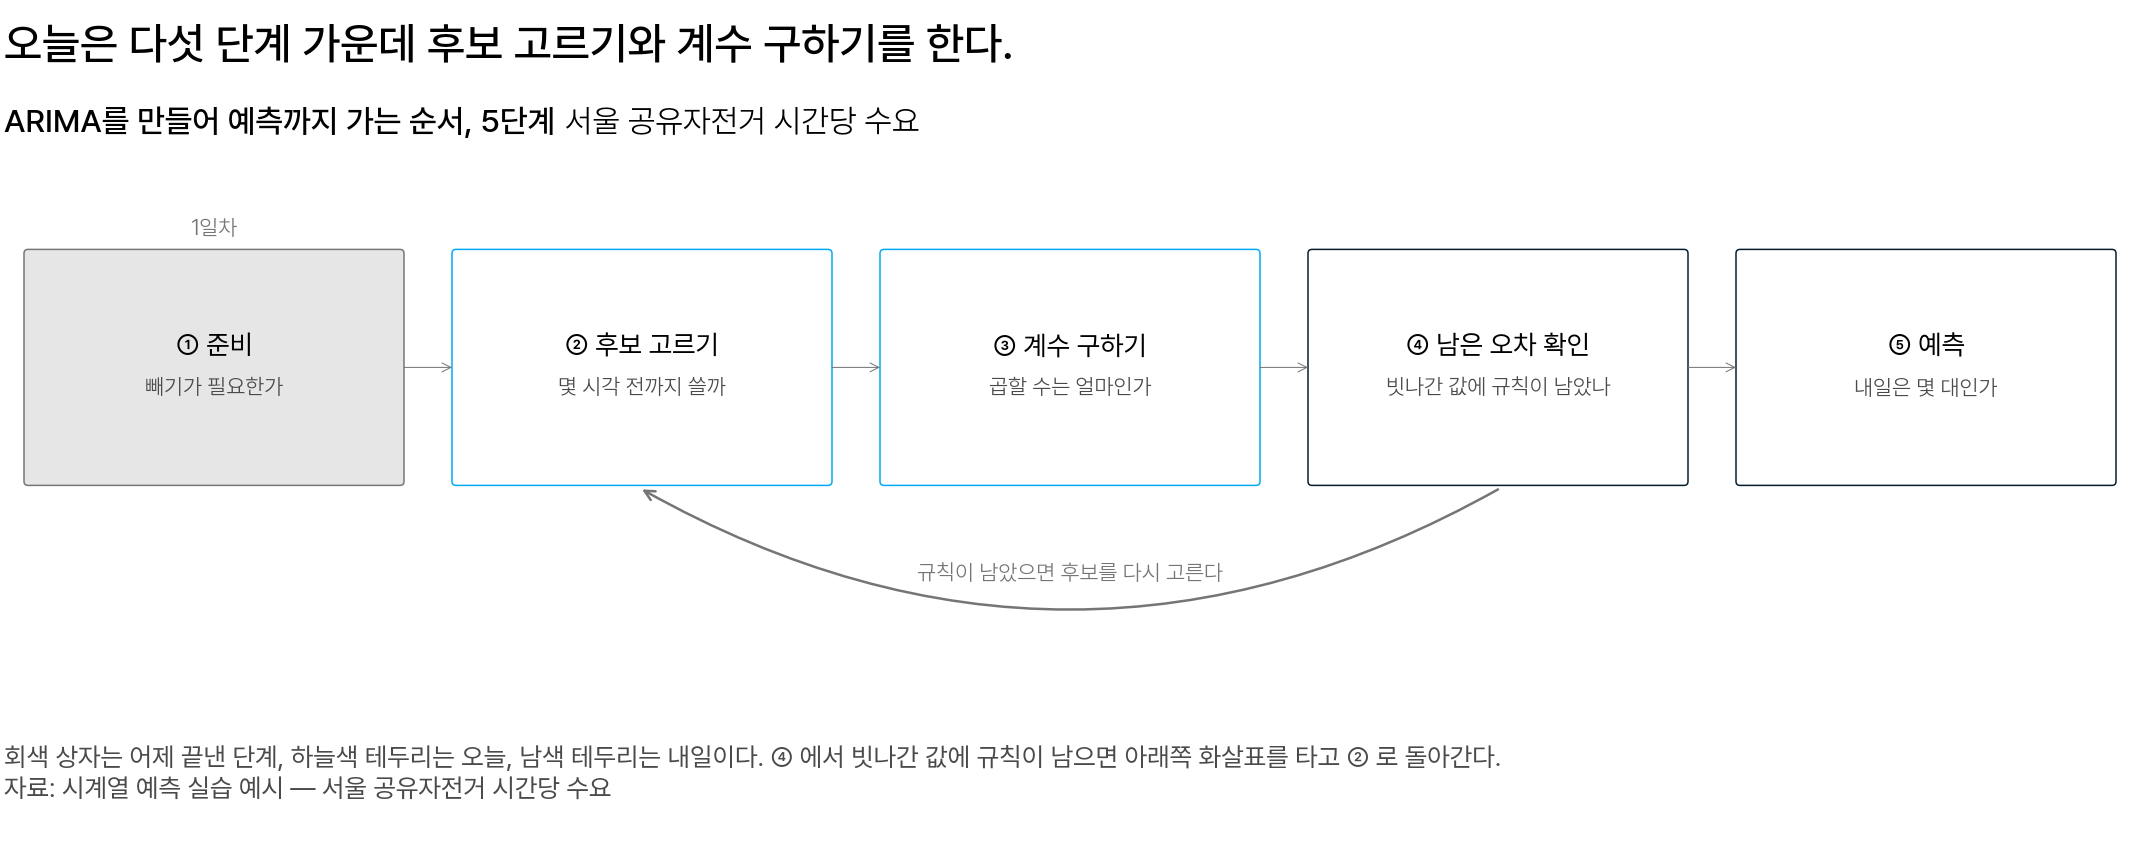

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 다섯 단계 가운데 오늘은 ②·③ — 어제 ① 에서 차분을 정했고, ④·⑤ 는 내일이다</em></p>

① 준비는 어제 끝냈고, 오늘은 ② 후보 고르기와 ③ 계수 구하기를 합니다.

ARIMA 는 수 3개를 정해 주어야 하는 모형이고, 그 세 수를 **차수**라 합니다. ARIMA(p, d, q) 로 적습니다.

p 에는 지난 값을 몇 개 쓸지 적습니다. d 에는 이웃한 두 시각의 값을 빼는 차분을 몇 번 했는지 적고, q 에는 지난 오차항을 몇 개 쓸지 적습니다.

어제 한 24시간 계절차분은 이웃한 두 시각의 뺄셈이 아닙니다. 24시간 떨어진 두 시각의 뺄셈이라 d 에 들어가지 않고, 이 계열의 d 는 0 입니다. (1, 0, 1) 이면 지난 값 1개 · 차분 0회 · 지난 오차항 1개입니다.

## 오늘의 순서

| 주제 |
|---|
| 1. 지난 값을 설명 변수로 쓰는 항 — AR |
| 2. 지난 오차항을 설명 변수로 쓰는 항 — MA |
| 3. AR·MA·차분의 결합 — ARIMA(p, d, q) |
| 4. 차수 후보를 좁히는 자기상관함수 |
| 5. 후보 선택 기준 AIC 와 자동 차수 탐색 |
| 6. 오늘의 정리와 팀 토론 질문 |

## 1. 지난 값을 설명 변수로 쓰는 항 — AR

다섯 단계 가운데 둘째, 후보 고르기입니다. ARIMA(p, d, q) 의 세 숫자 가운데 첫째 $p$ 부터 봅니다.

서울 공유자전거 시간당 수요라면, 직전 시각에 1,000대가 나갔을 때 이번 시각도 1,000대 근처겠거니 합니다. 그런데 이 감은 아직 식이 아닙니다. 이번 값이 직전 값의 몇 배쯤인지를 정해야 예측값이 나옵니다.

이렇게 자기 자신의 지난 값으로 이번 시각의 값을 적는 모형을 **자기회귀(autoregressive, AR)** 라 합니다. 오늘 기온을 어제 기온으로 짐작하는 일이 이 방법입니다. 이때 쓰는 지난 값이 설명 변수이고, 식에서 더하는 덩어리 하나를 항이라 합니다. 지난 값 하나만 쓰는 것이 AR(1) 입니다.

### AR(1) 의 식

$$
y_t = \underbrace{c}_{\text{상수항}} + \underbrace{\phi_1 y_{t-1}}_{\text{직전 값의 반영분}} + \underbrace{\varepsilon_t}_{\text{오차항}}
$$

- $y_t$ · $y_{t-1}$ : 이번 시각의 값과 한 시각 전의 값입니다. 여기서는 시간당 대여 수요(대)이고 한 시각은 1시간입니다.
- $\phi_1$ : **자기회귀 계수(autoregressive coefficient)** — 직전 값을 얼마나 반영할지 정합니다.
- $c$ : 계열 전체의 높이를 정하는 상수항입니다.
- $\varepsilon_t$ : **오차항(error term)** — 그 시각에 처음 생겨 앞의 두 항으로는 설명되지 않는 값이고, 평균이 0 입니다.

### 계수를 바꿔 대입해 보기

상수항을 3, 직전 값을 10 으로 두고 오차항은 0 으로 둡니다. 계수 $\phi_1$ 만 0.3 · 0.7 · 1.0 으로 바꿔 위 식에 대입합니다.

| $\phi_1$ | $3 + \phi_1 \times 10$ |
|---|---|
| 0.3 | 6 |
| 0.7 | 10 |
| 1.0 | 13 |

계수가 0.7 인 둘째 행을 봅니다. 직전 값 10 의 70%인 7 이 넘어오고, 남은 3 은 상수항이 채워 10 이 됩니다. 계수가 크면 직전 값이 그만큼 많이 넘어옵니다.

### 계열은 어디로 돌아가나

계수 0.7 인 계열을 10 에서 출발시키면 위 표의 둘째 행대로 다음 값도 10 이라 제자리입니다. 20 에서 출발하면 $3 + 0.7 \times 20 = 17$ 이고, 그다음은 14.9 로 내려옵니다. 계속하면 10 에 다가갑니다.

체온이 오르내려도 결국 평소 체온 근처입니다. 이 계열에도 그렇게 돌아가는 수준 하나가 있고, 그 수준을 **장기 평균(long-run mean)** 이라 합니다.

$$
\mu = \frac{c}{1 - \phi_1} = \frac{3}{1 - 0.7} = 10
$$

<details class="lms-extra"><summary>자세히 — 장기 평균 식은 어떻게 나오는가</summary>

위에서 다가간 그 10 이 어디서 나오는지 식으로 따라갑니다.

계열이 더는 변하지 않는 값을 $\mu$ 라 하겠습니다. 변하지 않는다는 말은 다음 값도 $\mu$ 라는 뜻이므로 $\mu = c + \phi_1 \mu$ 입니다.

양변에서 $\phi_1 \mu$ 를 뺍니다. $\mu - \phi_1 \mu = c$ 입니다.

왼쪽을 $\mu$ 로 묶습니다. $(1 - \phi_1)\mu = c$ 입니다.

양변을 $1 - \phi_1$ 로 나눕니다. 그래서 식이 $\mu = c / (1 - \phi_1)$ 이 됩니다.

계수를 바꾸면 돌아갈 수준도 바뀝니다. $\phi_1$ 이 0 이면 직전 값이 넘어오지 않아 장기 평균은 상수항 3 그대로입니다. $\phi_1$ 이 0.99 이면 장기 평균이 $3/(1-0.99) = 300$ 이고, 한 번 벗어난 값이 오래 남습니다.

</details>

### 계수가 1 이면 어떻게 되나

계수가 1.0 이면 분모 $1 - \phi_1$ 이 0 이라 돌아갈 수준이 없습니다. 직전 값이 그대로 넘어오고, 상수항 3 이 매 시각 더해져 값이 계속 커집니다.

그래서 AR(1) 은 $-1 < \phi_1 < 1$ 이어야 합니다. 이 조건을 **정상 조건(stationarity condition)** 이라 합니다. 정상성은 시간이 지나도 평균과 분산이 그대로인 상태이고, 이 부등식이 그 상태를 계수로 옮겨 적은 것입니다.

직전 값의 영향은 한 시각마다 $\phi_1$ 배로 줄어, $k$ 시각 뒤에는 $\phi_1^k$ 만 남습니다. 절댓값이 1 보다 작아야 이 값이 0 으로 갑니다.

조건 밖의 계열은 차분해 조건 안으로 옮깁니다. 차분은 직전 값과의 차이로 바꾸는 것이고, 그 횟수가 뒤에서 ARIMA(p, d, q) 의 둘째 숫자 $d$ 가 됩니다.

> **[예측] 상수항은 3, 출발점은 30 으로 똑같이 두고 오차항 300개도 같은 것을 씁니다. 계수만 0.3 과 1.0 으로 다릅니다. 시각 299 의 값은 어떻게 다를까요?**
>
> 1. 둘 다 출발점 30 근처에 있다
> 2. 0.3 은 장기 평균 4.3 근처로 내려왔고, 1.0 은 내려올 중심이 없어 계속 커져 있다
> 3. 둘 다 각자의 장기 평균으로 돌아갔다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

하나를 고른 뒤 아래 코드를 ▶ 로 실행합니다. 세 계열에 같은 오차항을 썼으니 결과가 다르면 원인은 계수뿐입니다.

In [ ]:
# 계수 phi 가 0.3, 0.9, 1.0 일 때 같은 오차항을 대입하면 어디로 이동하는가
import numpy as np

rng = np.random.default_rng(42)
eps = rng.normal(0, 1, 300)      # 계열 3개에 똑같이 대입할 오차항 300개
c, y0 = 3.0, 30.0                # 상수항과 출발점

print("  phi     t=10     t=100    t=299    이론 장기평균 c/(1-phi)")
for phi in (0.3, 0.9, 1.0):
    y = np.empty(300)
    y[0] = y0
    for t in range(1, 300):
        y[t] = c + phi * y[t - 1] + eps[t]
    m = f"{c / (1 - phi):8.1f}" if phi < 1 else "     없음"
    print(f"  {phi:.1f}  {y[10]:8.1f} {y[100]:8.1f} {y[299]:8.1f}   {m}")

#### 계수에 따라 값이 어디로 갔는가

답은 **둘째 보기**입니다.

- $\phi = 0.3$ : 시각 10 에서 이미 4.9 라 출발점 30 의 영향이 10시각 만에 사라졌고, 시각 299 에서 4.1 로 장기 평균 4.3 옆입니다.
- $\phi = 0.9$ : 시각 10·100·299 에서 28.5 · 25.6 · 27.9 로 장기 평균 30 을 오르내립니다. 출발점과 장기 평균이 같은 수라 멀리 가지 않았습니다.
- $\phi = 1.0$ : 시각 10 에서 57.2, 시각 100 에서 324.3, 시각 299 에서 **914.4** 로 커집니다.

**그래서** 0.9 와 1.0 의 차이는 0.1 이라는 간격이 아니라, 돌아갈 장기 평균이 있는지 없는지입니다.

### 계수의 부호와 개수가 만드는 모양

<img src="https://otexts.com/fpp3/fpp_files/figure-html/arp-1.png" width="640" height="288"/>
<p align="center"><em>▲ 계수가 정하는 AR 계열의 모양 — 모의 계열 100시각 (출처: fpp3 9.3)</em></p>

두 패널 모두 가로축은 시각, 세로축은 그 시각의 값입니다.

왼쪽은 항이 하나인 AR(1) 이고 계수가 −0.8 입니다. 계수가 음수라 직전 값이 부호만 반대로 바뀌어 넘어옵니다. 그래서 값이 한 시각마다 중심의 위아래를 오가는 지그재그가 됩니다.

오른쪽은 항이 둘인 AR(2) 입니다.

$$
y_t = 1.3\,y_{t-1} - 0.7\,y_{t-2} + \varepsilon_t
$$

직전 값을 1.3배로 이어 가려는 힘과, 두 시각 전 값의 0.7배만큼 반대로 당기는 힘이 함께 작용합니다. 미는 힘과 당기는 힘이 맞서면 값이 한 시각마다 튀지 못합니다. 대신 여러 시각에 걸쳐 천천히 커졌다 작아지는 물결이 됩니다. 오른쪽 패널에서 물결의 정점 하나에서 다음 정점까지를 세면 9시각쯤입니다.

항의 개수 $p$ 는 몇 시각 전까지 쓸지를 정하고, 모양은 계수가 정합니다.

<details class="lms-extra"><summary>더 깊이 — 과거를 여러 개 쓰는 AR(p)</summary>

과거를 $p$ 개까지 반영하면 **AR(p)** 이고, 이 $p$ 가 ARIMA(p, d, q) 의 첫 숫자입니다.

$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t
$$

- $p$ 를 키우면 반영하는 과거 시각이 늘어나고 추정할 계수도 그만큼 늘어납니다.

위 그림의 AR(2) 식에는 상수항을 적지 않았습니다. 상수항은 계열의 높이를 정하는 몫이라, 모양만 볼 때는 빼 둡니다.

앞의 $-1 < \phi_1 < 1$ 은 항이 하나일 때의 조건입니다. 항이 둘이면 두 계수를 함께 묶은 조건으로 바뀌고, AR(2) 에서는 부등식 셋입니다. $\phi_1 + \phi_2 < 1$ 이고, $\phi_2 - \phi_1 < 1$ 이고, $\phi_2$ 의 절댓값이 1 보다 작아야 합니다. 위 그림의 오른쪽 패널은 $\phi_1$ 이 1.3, $\phi_2$ 가 −0.7 이라 세 값이 차례로 0.6 · −2.0 · 0.7 이 되어 셋을 모두 만족합니다.

물결 하나의 길이는 $2\pi / \arccos\!\big(\phi_1 / (2\sqrt{-\phi_2})\big)$ 이고, 1.3 과 −0.7 을 넣으면 9.2 입니다.

</details>

### 자기상관(autocorrelation): 같은 계열의 지난 값과 견준 상관

계수가 크면 지난 값의 영향이 오래 남는다고 했습니다. 그 「오래」를 눈으로 세지 않고 수로 재는 것이 자기상관입니다.

한쪽 값이 오를 때 다른 쪽 값도 오르는지를 −1 과 1 사이 수 하나로 적은 것이 **상관(correlation)** 입니다. 같은 계열 안에서 $y_t$ 와 $y_{t-k}$ 를 비교해 얻은 상관이 **자기상관(autocorrelation)** $\rho(k)$ 입니다. 여기서 $k$ 는 몇 시각 전 값과 비교할지 정하는 수이고, 시차라 합니다.

AR(1) 에서는 $\rho(k) = \phi_1^{\,k}$ 입니다. 계수가 0.9 면 시차 1 은 $0.9^1 = 0.9$ 이고, 시차 2 는 $0.9^2 = 0.81$ 입니다. 시차가 커질수록 자기상관은 0 에 가까워집니다.

### [직접 해보기] 계수 φ 가 만드는 계열의 성격

화면의 `자기회귀 계수 φ` 가 본문의 $\phi_1$ 입니다. 이 화면은 상수항이 0 이라 계열이 0 을 중심으로 오르내립니다.

1. **해 보기.** 위쪽 탭에서 `AR(1) 자기회귀` 를 고르고 `자기회귀 계수 φ` 를 −0.9 에서 1.0 까지 움직입니다. 1.0 에서는 오른쪽에 `정상 조건 이탈` 이 뜹니다.
2. **관찰.** 아래 패널 `시차별 자기상관 ρ(k)` 의 막대 높이를 봅니다. 계수를 키우면 막대가 천천히 낮아집니다.
3. **확인 질문.** 계수를 0.9 로 두면 시차 5 의 막대에는 얼마가 남겠습니까. 0.1 근처인지 0.6 근처인지 정한 뒤 오른쪽 `시차 5 자기상관` 으로 확인합니다.

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/time-series/ar-ma-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 계수 0.9 에서 시차 5 자기상관의 값</summary>

AR 탭의 막대 높이는 계수의 거듭제곱입니다. 시차 $k$ 의 높이가 $\phi^k$ 이므로 시차 5 는 계수를 5회 곱한 값입니다. 계수를 0.9 로 두면 0.59 가 남으므로 **0.6 근처**가 답입니다. 계수를 0.3 에 두면 0.002 라서 화면에는 0.00 으로 뜹니다.

계수를 음수로 두면 막대가 $+, -, +, -$ 로 부호를 바꾸며 낮아집니다.

</details>

AR 은 직전 값에 계수를 곱해 이번 시각의 값에 더하는 항입니다. 그 계수의 절댓값이 1 보다 작아야 돌아갈 장기 평균이 생깁니다.

> **[문제] 위 코드가 출력한 표에서 t=299 값이 이론 장기 평균에서 벗어난 거리는 $\phi = 0.9$ 행이 $\phi = 0.3$ 행보다 멀다.**
>
> 1. O (맞다)
> 2. X (틀리다)

## 2. 지난 오차항을 설명 변수로 쓰는 항 — MA

앞에서 본 AR 은 지난 값을 썼습니다. 이번에는 예측이 빗나간 크기를 쓰는 항을 봅니다. ARIMA(p, d, q) 의 셋째 숫자 $q$ 가 이 항을 몇 개 둘지 정합니다.

직전 시각에 서울 공유자전거가 1,000대 나갔는데 예측은 900대였다고 합시다. 앞에서 본 오차항 $\varepsilon$ 이 바로 이 차이입니다. 실제 값에서 예측을 뺀 +100대가 직전 시각의 오차항 $\varepsilon_{t-1}$ 입니다. 어떤 시각은 이렇게 양수이고 어떤 시각은 음수라, 여러 시각의 오차항을 모아 평균을 내면 0 이 됩니다.

100대를 덜 봤다는 것은 그 시각에 알지 못한 사정이 있었다는 뜻입니다. 그 사정이 다음 시각에도 남아 있다면, 빗나간 크기를 다음 예측에 더하는 편이 낫습니다. 어제 예보가 빗나간 만큼을 오늘 예보에 반영하는 일기예보와 같습니다.

이렇게 지난 오차항에 계수를 곱해 더하는 모형을 **이동평균 모형(moving average model, MA)** 이라 합니다. 오차항 하나만 쓰는 것이 MA(1) 입니다. $q$ 개까지 쓰면 MA(q) 라 적습니다.

직전 오차항 +100대는 예측을 한 번 해 본 뒤에야 알 수 있는 값입니다. 그래서 계수를 먼저 정해 시각마다 예측과 오차항을 차례로 구합니다. 그 오차가 가장 작아지는 계수를 다시 찾는 일은 셋째 단계인 계수 구하기에서 함수 하나로 합니다.

### MA(1) 의 식

이번 시각의 값은 이렇게 만듭니다.

$$
y_t = \underbrace{\mu}_{\text{평균 수준}} + \underbrace{\varepsilon_t}_{\text{이번 오차항}} + \underbrace{\theta_1 \varepsilon_{t-1}}_{\text{직전 오차항의 반영분}}
$$

- $y_t$ : 시각 $t$ 의 값이고, 여기서는 시간당 대여 수요입니다.
- $\mu$ : 계열의 평균 수준입니다. 앞에서 AR 의 장기 평균이라 부른 그 값이고, 상수항 $c$ 대신 이 평균이 식에 들어갑니다.
- $\varepsilon_t$ : 이번 시각에 처음 나타난 오차항입니다.
- $\varepsilon_{t-1}$ : 직전 시각의 오차항이고, 앞에서 본 +100대가 그 값입니다.
- $\theta_1$ : **이동평균 계수**(moving average coefficient)입니다. 직전 오차항을 얼마나 반영할지 정합니다.

### 계수가 0.5 이면 이번 값은 얼마인가

식의 기호마다 수를 하나씩 대입합니다. 대여 수요와는 무관한 작은 수입니다.

| 식의 기호 | 이 예의 수 |
|---|---|
| 평균 수준 $\mu$ | 100 |
| 이동평균 계수 $\theta_1$ | 0.5 |
| 직전 오차항 $\varepsilon_{t-1}$ | +20 |
| 이번 오차항 $\varepsilon_t$ | 0 (아직 모르므로 평균으로 둡니다) |

직전 오차항 +20 은 이미 지나간 값이라 그대로 씁니다.

$$
E[y_t] = 100 + 0 + 0.5 \times 20 = 110
$$

직전 시각에 20 을 덜 본 것의 절반인 10 이 평균 수준 100 에 더해져 110 이 됩니다. 이번 오차항을 평균으로 두고 계산했으니 평균으로 기대되는 값이고, 그래서 기댓값 $E[y_t]$ 라 부릅니다.

<details class="lms-extra"><summary>자세히 — 오차항을 q 개로 늘린 MA(q) 의 일반형</summary>

위의 MA(1) 에서 오차항을 $q$ 개까지 늘려 적으면 다음과 같습니다.

$$
y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}
$$

- 항이 $q$ 개로 늘어난 것뿐이고, 계수 $\theta_1, \ldots, \theta_q$ 가 시차마다 하나씩 붙습니다.
- $\theta_3$ 이 크면 3시각 전 오차항이 이번 시각까지 넘어오고, 0 이면 3시각 전은 이번 시각과 무관합니다.

</details>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/maq-1.png" width="640" height="288"/>
<p align="center"><em>▲ 오차항만 써서 만든 MA 계열 100시각 — 계수가 몇 개이고 부호가 무엇이냐에 따라 오르내리는 모양이 달라진다 (출처: Hyndman & Athanasopoulos, fpp3 9.4)</em></p>

두 패널 모두 가로축은 시각, 세로축은 그 시각의 값입니다.

**MA(1)** — 평균 수준 20 에 계수 $\theta_1 = 0.8$ 하나로 만든 계열 100시각입니다. 값이 대체로 18 과 22 사이를 오르내립니다.

**MA(2)** — 오차항을 2개 쓰는 계열 100시각입니다. 평균 수준 $\mu$ 가 0 이라 식에서 빠집니다.

$$
y_t = \varepsilon_t - \varepsilon_{t-1} + 0.8\,\varepsilon_{t-2}
$$

직전 오차항에 곱한 계수 $\theta_1$ 이 −1 이고, 두 시각 전 오차항에 곱한 $\theta_2$ 가 0.8 입니다. $\theta_1$ 이 음수라 위로 튄 시각의 다음은 아래로 갑니다. 여기에 두 시각 전 오차항이 0.8배로 더해집니다. 그래서 이웃한 두 시각이 반대로 움직이면서도 값이 −5 와 +4 사이에 머뭅니다.

### 왜 MA 의 자기상관은 시차 q 뒤에서 0 이 되는가

오차항은 그 시각에 처음 생겨난 몫이라, 시각이 다르면 서로 아무 관계가 없다고 두고 계산합니다. 어제 예상 밖의 폭우가 온 일과 오늘 행사가 열린 일이 서로 상관없는 것과 같습니다. 그래서 두 시각이 같은 오차항을 함께 쓸 때만 $\rho(k)$ 가 0 이 아닙니다.

MA(1) 은 직전 1개의 오차항만 씁니다. 이웃한 두 시각을 나란히 적으면 이렇습니다.

$$
y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1}, \qquad
y_{t+1} = \mu + \varepsilon_{t+1} + \theta_1 \varepsilon_t
$$

두 식에 $\varepsilon_t$ 가 함께 들어 있습니다. 두 시각 떨어진 $y_t$ 와 $y_{t+2}$ 에는 함께 든 오차항이 하나도 없습니다. 그래서 시차 2 부터 자기상관이 정확히 0 입니다.

### 0 이 되는 절단(cut-off)과 줄어들기만 하는 감쇠(tail-off)

시차 $q$ 뒤에서 자기상관이 0 이 되는 것을 절단이라 합니다. 0 에 닿지 않고 줄어들기만 하면 감쇠라 합니다. 난방을 끈 방의 온도가 한 시간 뒤에도 조금 높게 남는 쪽이 감쇠입니다.

계수 하나가 $\rho(1)$ 을 정하고, 그 식이 $\rho(1) = \theta_1 / (1 + \theta_1^2)$ 입니다.

<details class="lms-extra"><summary>자세히 — 시차 1 자기상관 식은 어디서 나오는가</summary>

이 식은 「직전 오차항에 계수를 곱해 더하면 이웃한 두 시각이 얼마나 닮는가」를 수 하나로 적으려는 것입니다. 계수 0.5 를 그대로 대입해 계산해 봅니다. 오차항의 분산은 $\sigma^2$ 이라 적습니다.

1. 위의 두 식에서 $\theta_1$ 을 0.5 로 둡니다.
2. 평균 수준 $\mu$ 를 양쪽에서 뺍니다. 자기상관은 평균을 뺀 뒤의 값으로 계산하므로 $\mu$ 는 사라집니다.
3. 두 식을 곱해 평균을 냅니다. 서로 다른 오차항의 곱은 평균이 0 이라 사라지고, 함께 든 $\varepsilon_t$ 의 항만 남아 $0.5\,\sigma^2$ 이 됩니다. 이것이 두 시각의 공분산입니다.
4. 한 시각의 분산을 구합니다. $y_t$ 에 오차항이 2개 들어 있어 $\sigma^2 + 0.25\,\sigma^2 = 1.25\,\sigma^2$ 입니다.
5. 공분산을 분산으로 나눕니다. $\sigma^2$ 이 약분되어 $0.5 / 1.25 = 0.4$ 가 남습니다.

그래서 식이 $\rho(1) = \theta_1 / (1 + \theta_1^2)$ 이 됩니다. 계수를 양 끝에 두면 이렇습니다.

- $\theta_1 = 0$ : 남는 항이 $\mu$ 와 $\varepsilon_t$ 뿐이라 $\rho(1) = 0$ 입니다.
- $\theta_1 = 1$ : $\rho(1) = 1 / 2 = 0.5$ 이고, 더 키워도 이 0.5 를 넘지 못합니다.

</details>

### 왜 이름이 같은 rolling 평균과 계산이 다른가

`rolling(24).mean()` 은 이미 관측된 $y$ 값 24개를 평균 냅니다. MA 모형은 모형을 한 번 맞춰야 나오는 오차항에 계수를 곱해 더합니다.

한 시각 옮긴 rolling 평균은 그 24개 가운데 23개를 다시 씁니다. 입력이 23개나 겹치면 이웃한 두 값이 거의 같은 수가 되어 곡선이 완만해집니다. MA(1) 은 이웃한 두 시각이 오차항 하나만 함께 씁니다. 그래서 곡선을 매끄럽게 만들 때는 rolling 평균을 쓰고, 다음 값을 예측할 때는 MA 모형을 씁니다.

#### 만든 계열에서도 절단이 보이는가

같은 오차항 5,000개로 MA(1) 과 AR(1) 계열을 만듭니다. 계수는 두 모형 모두 0.8 로 맞췄습니다. 그래야 차이가 지난 값을 쓰느냐 지난 오차항을 쓰느냐에서만 옵니다.

In [ ]:
# MA(1) 의 자기상관은 시차 1 뒤에서 절단되고 AR(1) 은 감쇠한다
import numpy as np


def acf(x, lag):
    """표본 자기상관 - 평균을 뺀 뒤 lag 만큼 이동시켜 곱해 더하고 전체 제곱합으로 나눈다"""
    x = x - x.mean()
    return float((x[lag:] * x[:len(x) - lag]).sum() / (x * x).sum())


rng = np.random.default_rng(7)
e = rng.normal(0, 1, 5000)             # 계열 2개가 함께 쓸 오차항
ma1 = e[1:] + 0.8 * e[:-1]             # MA(1), theta = 0.8
ar1 = np.zeros(5000)                   # AR(1), phi = 0.8
for t in range(1, 5000):
    ar1[t] = 0.8 * ar1[t - 1] + e[t]

print("  시차   MA(1) 표본   MA(1) 이론   AR(1) 표본   AR(1) 이론")
for k in (1, 2, 3, 4, 5):
    theory_ma = 0.8 / (1 + 0.8 ** 2) if k == 1 else 0.0
    print(f"  {k:>2}      {acf(ma1, k):+.3f}       {theory_ma:+.3f}       "
          f"{acf(ar1, k):+.3f}       {0.8 ** k:+.3f}")

MA(1) 열을 세로로 읽으면 시차 1 에서 **+0.496** 이고 시차 2 에서 **+0.015** 입니다. AR(1) 열은 +0.811 에서 +0.358 까지 줄어들기만 합니다.

앞의 $\rho(1)$ 식에 계수 0.8 을 대입하면 분모가 $1 + 0.8^2 = 1.64$ 입니다. 그래서 이론값이 $0.8 / 1.64 = 0.488$ 이고, 표에 찍힌 표본값 +0.496 과 거의 같습니다. 시차 2 이상의 이론값은 0 이라 표본값 +0.015 도 0 에 가깝습니다.

**그래서** MA 는 절단하고 AR 은 감쇠합니다. 차수를 모르는 계열에서는 이 성질을 반대로 씁니다. 자기상관이 시차 1 뒤에서 0 으로 끊기면 $q = 1$ 을 후보로 두고, 끊기지 않고 줄어들기만 하면 AR 쪽 후보로 둡니다.

### [직접 해보기] 계수 θ 와 자기상관이 절단되는 시차

화면의 `이동평균 계수 θ` 는 본문의 $\theta_1$ 입니다.

1. **해 보기.** 위쪽 탭에서 `MA(1) 이동평균` 을 고르고 `이동평균 계수 θ` 를 0.8 로 둡니다.
2. **관찰.** 아래 패널 `시차별 자기상관 ρ(k)` 에서 막대가 시차 1 하나뿐인지 봅니다. 화면의 `시차 1 뒤에서 끊긴다` 와 `천천히 잦아든다` 가 본문의 절단과 감쇠입니다.
3. **확인 질문.** 계수를 0.8 에서 0.3 으로 낮추면 오른쪽 `시차 5 자기상관` 은 어떻게 되겠습니까. 0.0 그대로일지 0.2 로 올라갈지 정한 뒤 화면에서 확인합니다.

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/time-series/ar-ma-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 계수 θ 를 낮췄을 때 시차 5 자기상관</summary>

**0.0 그대로입니다.** MA(1) 의 이론 자기상관은 시차 1 에서만 $\theta_1 / (1 + \theta_1^2)$ 이고, 시차 2 부터는 곱할 계수가 아예 없어 0 입니다. 계수를 바꿔도 끊기는 시차는 1 뒤 그대로이고, 달라지는 것은 시차 1 막대의 높이뿐입니다. 화면의 `시차 1 자기상관 ρ(1)` 은 계수 0.8 에서 0.49, 0.3 에서 0.28 을 보여 줍니다.

0.2 를 골랐다면 계수가 막대 높이와 절단 시차를 같이 정한다고 읽은 것입니다. 절단 시차는 차수 $q$ 가 정하고, 계수는 높이만 정합니다.

</details>

MA 는 지난 오차항에 계수를 곱해 이번 시각의 값에 더하는 항입니다. 쓰는 오차항이 $q$ 개라 자기상관은 시차 $q$ 뒤에서 0 으로 끊깁니다.

> **[문제] 이동평균 모형과 rolling 평균이 입력으로 쓰는 값의 차이**
>
> 앞에서 출력한 표에서 MA(1) 표본 자기상관은 시차 1 에서 +0.496, 시차 2 에서 +0.015 였습니다. 표에는 없지만, 그 MA(1) 계열을 `rolling(24).mean()` 으로 매끄럽게 만든 곡선을 생각해 봅니다. 그 곡선의 자기상관도 시차 2 에서 0 근처로 감소할까요? 두 계산이 각각 무엇을 입력으로 삼는지를 근거로 예·아니오를 정하고, 이유를 2문장으로 적어 보세요.

## 3. AR·MA·차분의 결합 — ARIMA(p, d, q)

서울 공유자전거 수요에 지난 값만 쓸지, 지난 오차항까지 같이 쓸지는 아직 모릅니다. 그래서 둘을 함께 쓰는 식부터 적어 두고, 각각 몇 개를 둘지는 뒤에서 점수로 고릅니다.

지난 값과 지난 오차항을 함께 쓰는 모형을 **자기회귀이동평균**, 줄여서 **ARMA** 라 합니다. autoregressive moving average 의 약자입니다. 항을 하나씩만 둔 ARMA(1, 1) 은 이렇습니다.

$$
y_t = \underbrace{c}_{\text{상수항}} + \underbrace{\phi_1 y_{t-1}}_{\text{직전 값의 반영분}} + \underbrace{\varepsilon_t}_{\text{이번 오차항}} + \underbrace{\theta_1 \varepsilon_{t-1}}_{\text{직전 오차항의 반영분}}
$$

- $\phi_1$ : 자기회귀 계수이고, 직전 값을 얼마나 반영할지 정합니다.
- $\theta_1$ : 이동평균 계수이고, 직전 오차항을 얼마나 반영할지 정합니다.

네 항에 수를 하나씩 대입해 봅니다. 자기회귀 계수는 0.7, 이동평균 계수는 0.5 로 둡니다. 상수항은 300 으로 두고, 이번 오차항은 아직 나오지 않았으니 평균인 0 으로 둡니다. 직전 시각에 1,000대가 나갔고 그 시각 오차항은 앞에서 본 +100대입니다.

$$
y_t = 300 + 0.7 \times 1{,}000 + 0 + 0.5 \times 100 = 1{,}050
$$

직전 값에서 700대, 직전 오차항에서 50대, 상수항에서 300대가 모여 1,050대입니다. 이 계수에서 장기 평균은 $300/(1-0.7) = 1{,}000$대라 앞의 수요 수준과 맞습니다.

지난 값을 $p$ 개, 지난 오차항을 $q$ 개까지 늘리면 ARMA(p, q) 입니다.

### 값 대신 변화를 쓰는 차분

ARMA 는 값이 어떤 수준으로 돌아가는 계열에만 씁니다. 한 방향으로 커지기만 하는 계열에는 돌아갈 중심이 없으니, 값 대신 변화를 봅니다.

차분에는 두 가지가 있습니다. 어제 쓴 24시간 계절차분은 하루 전 같은 시각의 값을 뺐습니다. 지금 보는 **레벨 차분**(level differencing)은 바로 앞 시각의 값을 뺍니다. 체중 기록에 몸무게 대신 어제보다 몇 킬로그램 늘었는지 적는 일입니다.

$$
\underbrace{y'_t}_{\text{차분한 값}} = y_t - y_{t-1}
$$

시간당 대여 수요 3개로 이 뺄셈을 해 봅니다.

| 시각 $t$ | 대여 수요 $y_t$ | 차분한 값 $y'_t$ |
|---|---|---|
| 1 | 1,000대 | 없음 |
| 2 | 1,060대 | 60대 |
| 3 | 1,090대 | 30대 |

시각 3 의 차분한 값은 1,090 − 1,060 = 30대입니다. 첫 시각은 뺄 대상이 없어 값이 3개에서 2개로 줍니다.

오른쪽 열에는 1,000대라는 크기가 사라지고 60대·30대라는 변화만 남았습니다. 이 표를 한 번 더 차분하면 30 − 60 = −30 하나만 남습니다. 값이 2개에서 1개로 줄고, 수요가 몇 대였는지도 사라집니다. 그래서 레벨 차분 횟수 $d$ 는 보통 0 이나 1 로 둡니다.

### 차분 한 번에 오차항만 남는 계열 — 랜덤워크

첫날 다룬 **랜덤워크**(random walk)는 직전 값에 새 오차항을 더해 가는 계열입니다. 주가가 오늘 값에서 무작위로 오르내리는 모양이 이것입니다.

식으로는 $y_t = y_{t-1} + \varepsilon_t$ 이고, 양변에서 $y_{t-1}$ 을 빼면 $y_t - y_{t-1} = \varepsilon_t$ 만 남습니다. 서로 다른 시각의 오차항은 아무 관계가 없어, 차분한 계열은 어느 시차에서도 자기상관이 0 입니다. 이런 계열을 **백색잡음**(white noise)이라 합니다.

<img src="https://www.statsmodels.org/stable/_images/examples_notebooks_generated_statespace_sarimax_stata_9_0.png" width="640" height="197"/>
<p align="center"><em>▲ 왼쪽 미국 도매물가지수는 30 에서 116 까지 증가하지만 오른쪽 로그 차분 계열은 0 주변에서 오르내린다 — 차분이 하는 일이 이것이다 (출처: statsmodels)</em></p>

두 패널 모두 가로축은 연도이고, 세로축은 왼쪽이 지수 값, 오른쪽이 그 값에 로그를 씌운 뒤 차분한 값입니다.

왼쪽 패널은 미국 도매물가지수입니다. 1960년 30 근처에서 1991년 116 근처가 되어 돌아갈 수준 자체가 바뀝니다. ARMA 는 돌아갈 수준이 하나뿐이라 이런 계열에는 쓸 수 없습니다.

오른쪽 패널은 왼쪽과 같은 계열에 로그를 씌운 뒤 차분한 결과입니다. 값이 0 을 가로지르며 오르내립니다. 지수가 30 이던 때와 116 이던 때는 오르내리는 크기가 크게 다른데, 로그를 씌우면 그 크기가 비슷해집니다. 왼쪽을 오른쪽으로 바꾼 이 뺄셈이 차분이고, 몇 번 했는지가 $d$ 입니다.

### 차분과 ARMA 를 한 이름으로 묶기

$d$ 번 차분한 계열에 ARMA 를 쓰는 모형이 **ARIMA** 입니다. autoregressive integrated moving average 의 약자입니다. 식은 앞의 ARMA 와 같고, $y$ 를 차분한 값 $y'$ 로 바꿉니다.

$$
y'_t = c + \phi_1 y'_{t-1} + \cdots + \phi_p y'_{t-p} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}
$$

- $y'_t$ : $d$ 번 차분한 계열의 시각 $t$ 값입니다. 위 표의 $y'_3$ 은 30대입니다.
- $p$ · $d$ · $q$ : 지난 값의 개수, 차분 횟수, 지난 오차항의 개수입니다.

이 세 숫자를 괄호 안에 차례로 적습니다.

| 표기 | 우리말로 읽으면 |
|---|---|
| ARIMA(1, 0, 0) | 차분 없이 직전 값 1개, 곧 AR(1) |
| ARIMA(0, 0, 1) | 차분 없이 직전 오차항 1개, 곧 MA(1) |
| ARIMA(0, 1, 0) | 한 번 차분하면 백색잡음만 남는 계열, 곧 랜덤워크 |
| ARIMA(1, 1, 1) | 한 번 차분한 계열에 AR 1개와 MA 1개 |

ARIMA(1, 1, 0) 으로 위 표의 수를 대입해 봅니다. 상수항을 0, 자기회귀 계수를 0.5 로 두면 다음 차분값은 0.5 × 30 = 15대입니다. 이 15대는 대여 수요가 아니라 직전 시각과의 차이입니다. 그래서 시각 3 의 1,090대에 15대를 더해 1,105대를 예측값으로 적습니다.

차분한 횟수만큼 도로 더하는 이 덧셈이 ARIMA 가운데 글자 I, 곧 integrated 입니다.

### 레벨 차분을 몇 번 하는가

오늘 쓰는 계열은 어제 24시간 계절차분을 한 계열입니다. 여기서 정할 것은 레벨 차분을 몇 번 더 하느냐이고, 답은 어제 한 ADF 검정에 있습니다.

첫날 다룬 **단위근**(unit root)은 직전 값에 곱하는 계수 $\phi$ 가 정확히 1 인 상태입니다. 1 을 곱해도 값이 줄지 않아 한 번 튄 값이 그대로 남고, 평균 수준이 한 방향으로 밀려갑니다.

ADF 검정은 「단위근이 있다」를 맞다고 두고 시작합니다. 이렇게 맞다고 두는 문장을 **귀무가설**(null hypothesis)이라 합니다. ADF 통계량은 자료로 구한 계수가 1 에서 얼마나 떨어져 있는지를 재고, 멀수록 더 작은 음수가 됩니다.

24시간 계절차분한 계열의 ADF 통계량은 −17.02 였고, 5% **임계값**(critical value)은 −2.86 입니다. −17.02 는 그보다 훨씬 작으니 「단위근이 있다」를 버렸고, 이렇게 버리는 것을 **기각**이라 합니다. 레벨 차분은 더 하지 않으니 ARIMA(p, d, q) 의 $d$ 가 0 입니다.

<details class="lms-extra"><summary>더 깊이 — ADF 통계량의 뜻, 두 검정의 결론이 갈린 까닭, 차분을 모형에 맡기는 까닭</summary>

ADF 통계량은 자료로 구한 계수에서 1 을 뺀 값을 **표준오차**(standard error)로 나눈 값입니다. 표준오차는 같은 계열에서 자료를 다시 모아 계수를 구하면 그 계수가 이만큼씩 달라진다는 값입니다. 계수가 1 에서 멀수록, 그리고 표준오차가 작을수록 통계량은 더 작은 음수가 됩니다. 5% 임계값 −2.86 은 단위근이 정말 있는 계열에서 자료를 100번 새로 모아 통계량을 100개 구하면 그 가운데 5개가 이 값보다 작다는 뜻입니다.

첫날 원본 수요 8,760시간에서는 ADF 통계량 −6.95 가 「단위근이 있다」를 기각했는데, KPSS 통계량 8.005 는 「정상이다」도 기각했습니다. KPSS 는 「정상이다」가 귀무가설이라 5% 임계값 0.463 보다 크면 기각합니다. 두 검정의 결론이 갈린 것입니다.

원인은 하루 주기입니다. KPSS 는 평균 수준이 시점에 따라 달라지는지를 봅니다. 8,760시간 계열에는 하루 주기가 남아 있어 구간을 어디로 잡느냐에 따라 평균이 달라지고, 통계량 8.005 가 그 차이의 크기입니다. 레벨 차분으로는 하루 주기가 지워지지 않으니 여기에 필요한 것은 계절차분이었습니다.

차분은 첫날 `diff()` 로 직접 해 보았습니다. 그런데도 $d$ 를 모형 안에 두는 까닭은 복원입니다. 직접 차분하면 예측이 「다음 시각과 이번 시각의 차이」로 나와 이번 값에 더해야 합니다. $d$ 를 모형 안에 두면 이 덧셈과 예측구간의 복원을 모형이 함께 합니다.

다만 $d$ 를 맡긴다는 것은 계산을 맡긴다는 뜻이지, 몇 번 차분할지를 맡긴다는 뜻이 아닙니다.

</details>

ARIMA(p, d, q) 는 $d$ 번 차분한 계열을 지난 값 $p$ 개와 지난 오차항 $q$ 개로 설명합니다. 이 세 숫자는 데이터에 적혀 있지 않으니, 다음에는 자기상관 그림으로 후보를 좁힙니다.

> **[문제] ARIMA(1, 1, 0) 의 예측값을 원본 단위로 복원하기**
>
> 위 표의 대여 수요는 1,000대 · 1,060대 · 1,090대이고 차분한 값은 60대와 30대입니다. 본문은 상수항 0, 자기회귀 계수 0.5 로 다음 차분값 15대와 원본 단위 예측값 1,105대를 얻었습니다. 자기회귀 계수가 0.5 가 아니라 −0.2 라면 다음 차분값과 원본 단위 예측값은 각각 얼마입니까. 계산을 두 줄로 적고, 원본 단위로 복원하는 덧셈이 왜 필요한지 한 문장으로 적어 보세요.

## 4. 차수 후보를 좁히는 자기상관함수

다섯 단계 가운데 둘째인 후보 고르기를 이어 갑니다. ADF 검정에서 이 계열의 $d$ 는 0 으로 정했고, 남은 것은 $p$ 와 $q$ 입니다.

계열을 그린 선만 보아서는 지금 값이 몇 시각 전 값과 함께 움직이는지 알 수 없습니다.

**자기상관함수(autocorrelation function, ACF)** 는 $k$ 시각 떨어진 두 값을 비교합니다. 한 쌍만 보는 것이 아니라, 계열 전체에서 그런 두 값을 모두 봅니다. 그 값들이 함께 높아지고 함께 낮아지는 정도를 −1 과 1 사이 수 하나로 적습니다.

$$
r_k = \frac{\sum_{t=k+1}^{T} (y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{T} (y_t - \bar{y})^2}
$$

- $r_k$ : 자료로 계산한 시차 $k$ 의 자기상관입니다. 앞에서 식으로 구한 $\rho(k)$ 와 구별해 로마자 $r$ 로 적습니다.
- $y_t$ · $y_{t-k}$ : 이번 시각의 값과 $k$ 시각 전의 값이고, 시간당 대여 수요(대)입니다.
- $\bar{y}$ · $T$ : 그 구간의 평균과 자료 수입니다.
- 분자 : 두 값이 평균에서 같은 쪽으로 벗어나면 곱이 양수가 되어 합이 커지고, 엇갈리면 음수가 되어 작아집니다.
- 분모 : 분자를 −1 과 1 사이로 맞춰 주는 크기입니다.

이 식에 실제 값을 대입해 봅니다. 11월 3일 08시부터 12시까지 대여 수요는 713대 · 785대 · 898대 · 996대 · 1,076대입니다.

다섯 값의 평균은 893.6대입니다. 각 값에서 평균을 뺀 다음 이웃한 두 값끼리 곱해 더하면 분자 38,264 가 나옵니다. 뺀 값을 각각 제곱해 더한 88,185 가 분모입니다.

$$
r_1 = \frac{38{,}264}{88{,}185} = 0.43
$$

한 시각 전 값과 이번 값이 0.43 만큼 함께 움직였다는 뜻입니다.

<details class="lms-extra"><summary>자세히 — 분자 38,264 는 어떤 곱 네 개를 더한 것인가</summary>

평균을 뺀 값은 −180.6 · −108.6 · +4.4 · +102.4 · +182.4 입니다. 시차 1 이면 이웃한 두 값끼리 곱하므로 곱이 네 개 나옵니다.

| 곱하는 두 값 | 곱 |
|---|---|
| (−180.6) × (−108.6) | +19,613 |
| (−108.6) × (+4.4) | −478 |
| (+4.4) × (+102.4) | +451 |
| (+102.4) × (+182.4) | +18,678 |

음수는 둘째 곱 하나뿐입니다. 785대는 평균보다 작고 898대는 평균보다 커서 부호가 엇갈리기 때문입니다.

</details>

$k$ 를 1, 2, 3, … 으로 바꿔 가며 $r_k$ 를 구해 막대로 그리면 ACF 그림이 됩니다. 맨 왼쪽 시차 0 의 막대는 자기 자신과의 상관이라 언제나 1 이고, 읽을 것은 그 오른쪽부터입니다.

AR(1) 에서 이번 값은 직전 값에 계수를 곱한 것이라, $k$ 시각 전 값의 영향은 계수를 $k$ 번 곱한 만큼 남습니다. 계수가 0.8 이면 시차 2 의 자기상관은 $0.8^2 = 0.64$ 입니다. 이렇게 모형 식에서 바로 나오는 값을 이론 자기상관이라 하고, 자료로 계산한 막대는 그 값 근처에서 흔들립니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Acf_new.svg" width="330" height="439"/>
<p align="center"><em>▲ 모의 계열 100시각(위)과 그 자기상관함수(아래) (출처: Wikipedia, Autocorrelation)</em></p>

**위 — 모의 계열 100시각.** 가로축은 시각, 세로축은 그 시각의 값입니다.

**아래 — 그 계열의 ACF.** 가로축은 시차 $k$, 세로축은 그 시차의 자기상관입니다. 시차 4 부터 6 까지는 −0.4 근처로 아래쪽 점선 밖에 있습니다. 시차 4 의 막대가 아래로 뻗은 것은 4시각 전이 높으면 지금은 낮다는 뜻입니다.

### 경계선: 자기상관을 0 으로 볼지 가르는 두 선

자기상관이 정말 0 인 계열이라도 자료가 100개뿐이면 막대는 딱 0 이 되지 않고 0 근처에서 흔들립니다. 그런 계열을 같은 길이로 100번 새로 만들어, 시차 1 의 막대만 100개 모아 봅니다. 그 100개 가운데 95개가 들어오는 구간이 그림의 가로 점선 2개입니다.

이 두 선을 **경계선(significance bounds)** 이라 하고, 선의 위치는 자료 수가 정합니다.

$$
\pm \frac{1.96}{\sqrt{T}}
$$

- $T$ : 그 계열의 자료 수입니다.
- 1.96 : 흔들림의 95% 를 담는 구간 길이를 정하는 수이고, 이 95% 는 관행으로 씁니다.

위 그림은 자료가 100개라 경계선이 $\pm 1.96/\sqrt{100} = \pm 0.20$ 입니다. 막대가 이 선 바깥이면 그 시차의 자기상관을 0 이 아니라고 읽고, 안쪽이면 0 으로 읽습니다.

<details class="lms-extra"><summary>더 깊이 — 자료 수가 경계선을 어떻게 바꾸나, 바깥은 무엇을 뜻하지 않나</summary>

- 자료가 25개뿐이면 ±0.39 로 넓어져 0.3 크기의 막대도 안쪽에 들어옵니다.
- 1년치 8,760시간이면 ±0.021 로 좁아져 0.03 크기의 막대도 바깥으로 나옵니다.

막대가 경계선 바깥이라는 것은 과거 값과 현재 값이 함께 움직인다는 뜻입니다. 과거 값이 현재 값의 원인이라는 뜻은 아닙니다. 둘 다 바깥 요인 하나에 함께 끌려다녀도 막대는 높이 올라갑니다.

자료 수가 같으면 선의 위치도 같습니다. 계수가 0.8 인 AR(1) 을 자료 100개로 만들면 이론 자기상관이 $0.8^7 = 0.21$ 인 시차 7 까지 ±0.20 바깥이고, 시차 8 의 0.17 부터 안쪽입니다.

</details>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/egyptacf-1.png" width="640" height="192"/>
<p align="center"><em>▲ 이집트의 GDP 대비 수출 비중(연간) 자기상관함수 (출처: fpp3 9.5)</em></p>

### 왜 이 그림만으로는 차수를 하나로 정할 수 없는가

막대는 시차 1 의 +0.83 에서 시차 8 의 −0.42 까지 부호를 바꾸며 감쇠합니다. 가로축 눈금의 lag [1Y] 는 시차 단위가 1년이라는 뜻입니다.

이 그림의 시차 14 막대는 위쪽 경계선에 닿아 있어, 한 해치를 더 쓰거나 덜 쓰면 안과 밖이 바뀝니다. 그러면 읽는 사람마다 차수가 갈립니다.

**자기상관 그림은 후보를 서너 개로 좁히는 데까지이고, 확정은 뒤에서 AIC 로 합니다.**

<img src="https://otexts.com/fpp3/fpp_files/figure-html/acfstationary-1.png" width="640" height="224"/>
<p align="center"><em>▲ 구글 종가 원본(왼쪽)과 하루 변화량(오른쪽)의 자기상관함수 (출처: fpp3 9.1)</em></p>

### 느린 감쇠: 차분이 덜 됐다는 신호

**왼쪽 — 구글 종가 원본.** 막대가 시차 1 의 1.0 가까이에서 시차 24 까지도 0.5 아래로 내려오지 않습니다. 이렇게 천천히 낮아지는 형태를 **느린 감쇠(slow decay)** 라 합니다.

**오른쪽 — 하루 변화량.** 같은 계열을 하루 차이로 바꾸면 막대가 거의 전부 경계선 안쪽으로 들어옵니다. 체중계 눈금은 어제 값과 거의 같지만, 하루 사이 늘고 준 양은 서로 닮지 않기 때문입니다.

그래서 $d$ 를 먼저 정하고 나서 후보를 읽습니다.

### 부분자기상관함수: 사이 시차를 빼고 남는 상관

ACF 하나로는 $p$ 와 $q$ 를 가르지 못합니다. **부분자기상관함수(partial autocorrelation function, PACF)** 를 함께 봅니다. 사이에 낀 시차의 영향을 뺀 뒤 남는 상관입니다.

시차 2 의 자기상관에는 시차 1 을 두 번 거쳐 전해진 양이 들어 있습니다. 그 양을 빼고 남는 값이 시차 2 의 부분자기상관입니다.

지난 값 둘을 함께 쓴 식으로 보면 이렇습니다.

$$
y_t = \phi_{21} y_{t-1} + \phi_{22} y_{t-2} + \varepsilon_t
$$

첨자 앞의 2 는 지난 값을 2개 쓴 식이라는 표시이고, 뒤의 1 과 2 는 몇 시각 전 값에 곱하는 계수인지입니다.

- $\phi_{21}$ : 한 시각 전 값에 곱하는 계수입니다.
- $\phi_{22}$ : 두 시각 전 값에 곱하는 계수이고, 이것이 시차 2 의 부분자기상관입니다. 한 시각 전 값으로 설명될 몫은 $\phi_{21}$ 이 먼저 가져갑니다.

계수가 0.8 인 AR(1) 로 확인해 봅니다. 시차 2 의 이론 자기상관은 0.64 이고, 한 시각마다 0.8 씩 전해지니 두 번 거쳐 온 양도 0.8 × 0.8 = 0.64 입니다. 두 값이 같아 0.64 − 0.64 = 0 이 남고, $\phi_{22}$ 는 0 이 됩니다.

| | AR(p) 계열 | MA(q) 계열 |
|---|---|---|
| **ACF** | 서서히 감쇠 | 시차 $q$ 뒤에서 절단 |
| **PACF** | 시차 $p$ 뒤에서 절단 | 서서히 감쇠 |

부호를 바꾸며 줄어드는 것도 감쇠에 듭니다.

표대로 한쪽이 절단되는 것은 $p$ 와 $q$ 중 하나가 0 인 계열입니다. 둘 다 1 이상이면 두 함수가 모두 감쇠만 하고, 실제 자료는 이쪽이 흔합니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/egyptpacf-1.png" width="640" height="192"/>
<p align="center"><em>▲ 앞에서 자기상관함수를 본 그 이집트 수출 비중 계열의 부분자기상관함수 (출처: fpp3 9.5)</em></p>

가로축은 시차, 세로축은 사이 시차의 영향을 뺀 상관입니다. 자기상관함수는 부호를 바꾸며 감쇠했고, 부분자기상관함수는 시차 4 뒤로 경계선 안쪽에 머뭅니다. 대조표의 AR 쪽이라 이 계열의 $p$ 후보는 4 입니다.

### 서울 공유자전거 수요에서 후보 넷으로 좁히기

학습 구간은 11월 3일부터 16일까지 336시간이고, 어제 고른 24시간 계절차분을 한 계열입니다. 24시간 전 값을 빼면 앞 24개가 잘려 남는 값이 312개이고, 경계선은 $\pm 0.11$ 입니다.

이 계열의 두 함수를 앞의 그림들과 같은 방식으로 구해 봅니다. 자기상관함수는 시차 1 에서 0.87, 시차 2 에서 0.72, 시차 3 에서 0.62 로 천천히 낮아집니다. 끊기는 시차는 없습니다.

부분자기상관함수는 시차 1 의 0.87 이 가장 크고, 시차 2 의 −0.14 와 시차 3 의 0.12 는 경계선에 겨우 걸칩니다. 그 뒤로 시차 11 과 25 에 막대가 하나씩 남지만, 앞쪽 시차부터 정하는 것이 순서라 이 둘은 내일 다시 봅니다.

대조표에서 자기상관함수가 감쇠하고 부분자기상관함수가 끊기는 쪽은 AR 입니다. 부분자기상관함수가 시차 1 에서 끊긴 것으로 읽으면 $p$ 는 1 이고, AR 만 쓴 (1, 0, 0) 이 첫 후보입니다.

자기상관함수는 끊기는 시차가 없어 $q$ 를 그림으로 정하지 못합니다. 그래서 지난 오차항을 쓰는 항을 하나만 더한 (1, 0, 1) 을 함께 둡니다. 경계선에 걸친 시차 2 까지 $p$ 를 넓혀 읽으면 (2, 0, 1) 이 나옵니다.

여기에 자기상관함수를 절단으로 읽는 사람의 (0, 0, 1) 을 더해 후보가 넷입니다.

### [직접 해보기] 답을 아는 계열에서 읽는 자기상관 형태

화면의 `acf` 와 `pacf` 는 본문의 ACF 와 PACF 이고, `대역` 은 경계선입니다. 각주의 ±2/√T 는 ±1.96/√T 의 어림값입니다.

1. **해 보기.** `자기회귀 차수 p` 를 2 로, `이동평균 차수 q` 를 0 으로 둡니다. 위쪽 탭은 `시차 12` 로 둡니다.
2. **관찰.** 오른쪽 아래 `대역 밖 시차 수` 는 acf 와 pacf 순으로 수 2개를 보여 줍니다. 뒤쪽 pacf 의 수가 더 작으면 pacf 가 먼저 절단된 것이고, 대조표의 AR 쪽과 같습니다.
3. **확인 질문.** 이번에는 `이동평균 차수 q` 만 2 로, `자기회귀 차수 p` 는 0 으로 둡니다. 위 대조표대로면 패널 2개 가운데 어느 쪽이 시차 2 뒤에서 절단되겠습니까.

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/time-series/acf-pacf-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 절단되는 패널</summary>

**가운데 acf 패널입니다.** `이동평균 차수 q` 2 · `자기회귀 차수 p` 0 은 순수 MA(2) 입니다. 시차 2 까지만 오차항을 함께 쓰고 그 뒤로는 함께 쓰는 오차항이 없습니다. 그래서 acf 막대가 시차 2 뒤에서 경계선 안쪽으로 들어가고, pacf 는 완만하게 감쇠하기만 합니다.

대조표에서 MA 열을 세로로 읽은 것과 같습니다. 다만 참값이 0 이어도 막대 1개는 우연히 경계선 바깥으로 나올 수 있습니다.

</details>

> **[문제] 자료 수 T 가 늘어나면 경계선 ±1.96/√T 는 넓어진다.**
>
> O 를 고르게 하는 것은 「자료가 많으면 여유가 커진다」는 짐작입니다. 여기서 늘어나는 것은 0 과 구별하는 정밀도이고, 경계선은 오히려 좁아집니다. 자료가 많을수록 작은 자기상관도 0 이 아니라고 볼 수 있습니다.
> 스스로 확인하려면 $T$ 에 400 을 대입해 보세요. $1.96 / \sqrt{400} = 0.098$ 이라 100개일 때의 0.20 보다 좁습니다.
> 실무에서는 자료가 아주 많을 때 경계선 바깥 막대가 여럿 서는 일이 흔합니다. 그때는 막대가 바깥인지만 보지 말고 값의 크기가 쓸 만한지도 함께 봅니다.
>
> 1. O (맞다)
> 2. X (틀리다)

## 5. 후보 선택 기준 AIC 와 자동 차수 탐색

앞에서 자기상관함수와 부분자기상관함수로 좁힌 후보 가운데 하나를 고릅니다. 차수를 고르고 나면 셋째 단계인 계수 구하기로 넘어갑니다.

데이터에서 값을 추정해야 하는 수를 **모수(parameter)** 라 합니다. 계수와 상수항과 오차항의 분산이 모수이고, AR(2) 라면 계수 2개에 둘을 더해 4개입니다.

모수를 늘리면 데이터를 설명하는 정도는 언제나 좋아집니다. 항을 하나 더 받은 모형은 그 계수를 0 으로 두면 이전 모형과 같아지기 때문입니다. 그래서 설명하는 정도만 비교하면 항이 가장 많은 후보가 늘 이깁니다.

설명하는 정도는 **로그우도(log-likelihood)** 로 적습니다. 계수를 정해 두고 관측마다 그 값이 나올 법한 정도(확률밀도)를 구해 모두 곱한 뒤 로그를 씌운 값입니다.

<details class="lms-extra"><summary>자세히 — 로그우도를 작은 수로 계산해 보기</summary>

관측 $T$ 개의 확률밀도를 $f_1$ 부터 $f_T$ 까지 적으면 로그우도는 이렇게 됩니다.

$$
\ln \hat{L} = \ln (f_1 \times f_2 \times \cdots \times f_T)
$$

- $f_t$ : $t$ 번째 관측이 나올 확률밀도입니다.
- $T$ : 적합에 쓴 관측의 개수입니다.

밀도가 0.3, 0.2, 0.1 인 관측 3개라면 $\ln(0.3 \times 0.2 \times 0.1) = \ln 0.006 = -5.12$ 입니다. 1 보다 작은 밀도를 여럿 곱하면 곱이 0 에 가까워지고, 거기에 로그를 씌우니 로그우도는 대개 음수로 나옵니다.

</details>

잘 설명하면서 모수는 적게 쓴 후보를 고를 점수가 필요합니다. **AIC(Akaike information criterion, 아카이케 정보 기준)** 가 그 점수입니다.

$$
\text{AIC} = \underbrace{2k}_{\text{모수 개수만큼 더하는 항}} - \underbrace{2\ln \hat{L}}_{\text{설명한 정도}}
$$

- $\ln \hat{L}$ : 계수를 자료에 가장 잘 맞는 값으로 정하는 일을 **적합(fitting)** 이라 합니다. 적합이 고른 계수에서의 로그우도이고, 클수록 잘 설명한 것입니다.
- $k$ : 추정한 모수의 개수이고, 앞에서 쓴 시차 $k$ 와는 다른 수입니다.
- $2k$ : **패널티 항(penalty term)** 이라 부르고, 모수 하나마다 2 씩 더합니다.

잘 설명할수록 값이 내려가고, 모수를 늘리면 $2k$ 때문에 도로 커집니다. 그래서 AIC 는 낮을수록 좋은 점수이고, 후보 여럿 가운데 가장 낮은 것을 고릅니다.

> **[예측] 자기회귀 차수 p 를 1에서 6까지 증가시키면 로그우도와 AIC 는 각각 어떻게 달라질까요?**
>
> 1. 둘 다 계속 좋아진다
> 2. 로그우도는 계속 증가하지만 AIC 는 최솟값을 지난 뒤 다시 증가한다
> 3. 로그우도는 최댓값을 지난 뒤 감소하고 AIC 는 최솟값을 지난 뒤 증가한다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

하나를 고른 뒤 아래 코드를 실행합니다.

### 차수를 이미 아는 계열에서 확인하기

AIC 가 맞는 차수를 고르는지 보려면, 차수를 이미 아는 계열에 써 보면 됩니다. 계수 0.6 과 −0.3 으로 차수가 2인 AR 계열을 만듭니다.

$$
y_t = 0.6\,y_{t-1} - 0.3\,y_{t-2} + \varepsilon_t
$$

여기에 $p$ 를 1 부터 6 까지 바꿔 가며 적합합니다. 아래 코드는 오차 제곱의 합이 가장 작아지는 **최소제곱**으로 계수를 정합니다.

In [ ]:
# 차수 p 를 1에서 6까지 증가시키며 로그우도와 AIC 를 나란히 출력한다
import numpy as np

rng = np.random.default_rng(0)
n, PMAX = 400, 6
e = rng.normal(0, 1, n)
y = np.zeros(n)
for t in range(2, n):                  # 참 모형: AR(2), 계수 0.6 과 -0.3
    y[t] = 0.6 * y[t - 1] - 0.3 * y[t - 2] + e[t]


def fit_ar(y, p, pmax):
    """최소제곱으로 AR(p) 를 적합하고 (로그우도, AIC) 를 돌려준다.

    관측 구간을 pmax 로 고정해 모든 p 가 같은 관측 394 개를 쓰게 맞춘다.
    """
    target = y[pmax:]
    cols = [y[pmax - k:len(y) - k] for k in range(1, p + 1)] + [np.ones(len(target))]
    design = np.column_stack(cols)
    beta = np.linalg.lstsq(design, target, rcond=None)[0]
    resid = target - design @ beta
    s2 = float((resid * resid).mean())
    loglik = -0.5 * len(target) * (np.log(2 * np.pi * s2) + 1)
    k = p + 2                          # 자기회귀 계수 p 개 + 상수항 + 오차항 분산
    return loglik, 2 * k - 2 * loglik


rows = [fit_ar(y, p, PMAX) for p in range(1, PMAX + 1)]
best = min(range(len(rows)), key=lambda i: rows[i][1])   # AIC 가 가장 낮은 행

print("   p   로그우도       AIC")
for p in range(1, PMAX + 1):
    loglik, aic = rows[p - 1]
    mark = "  <- AIC 최소" if p - 1 == best else ""
    print(f"  {p:2d}  {loglik:9.2f}  {aic:9.2f}{mark}")

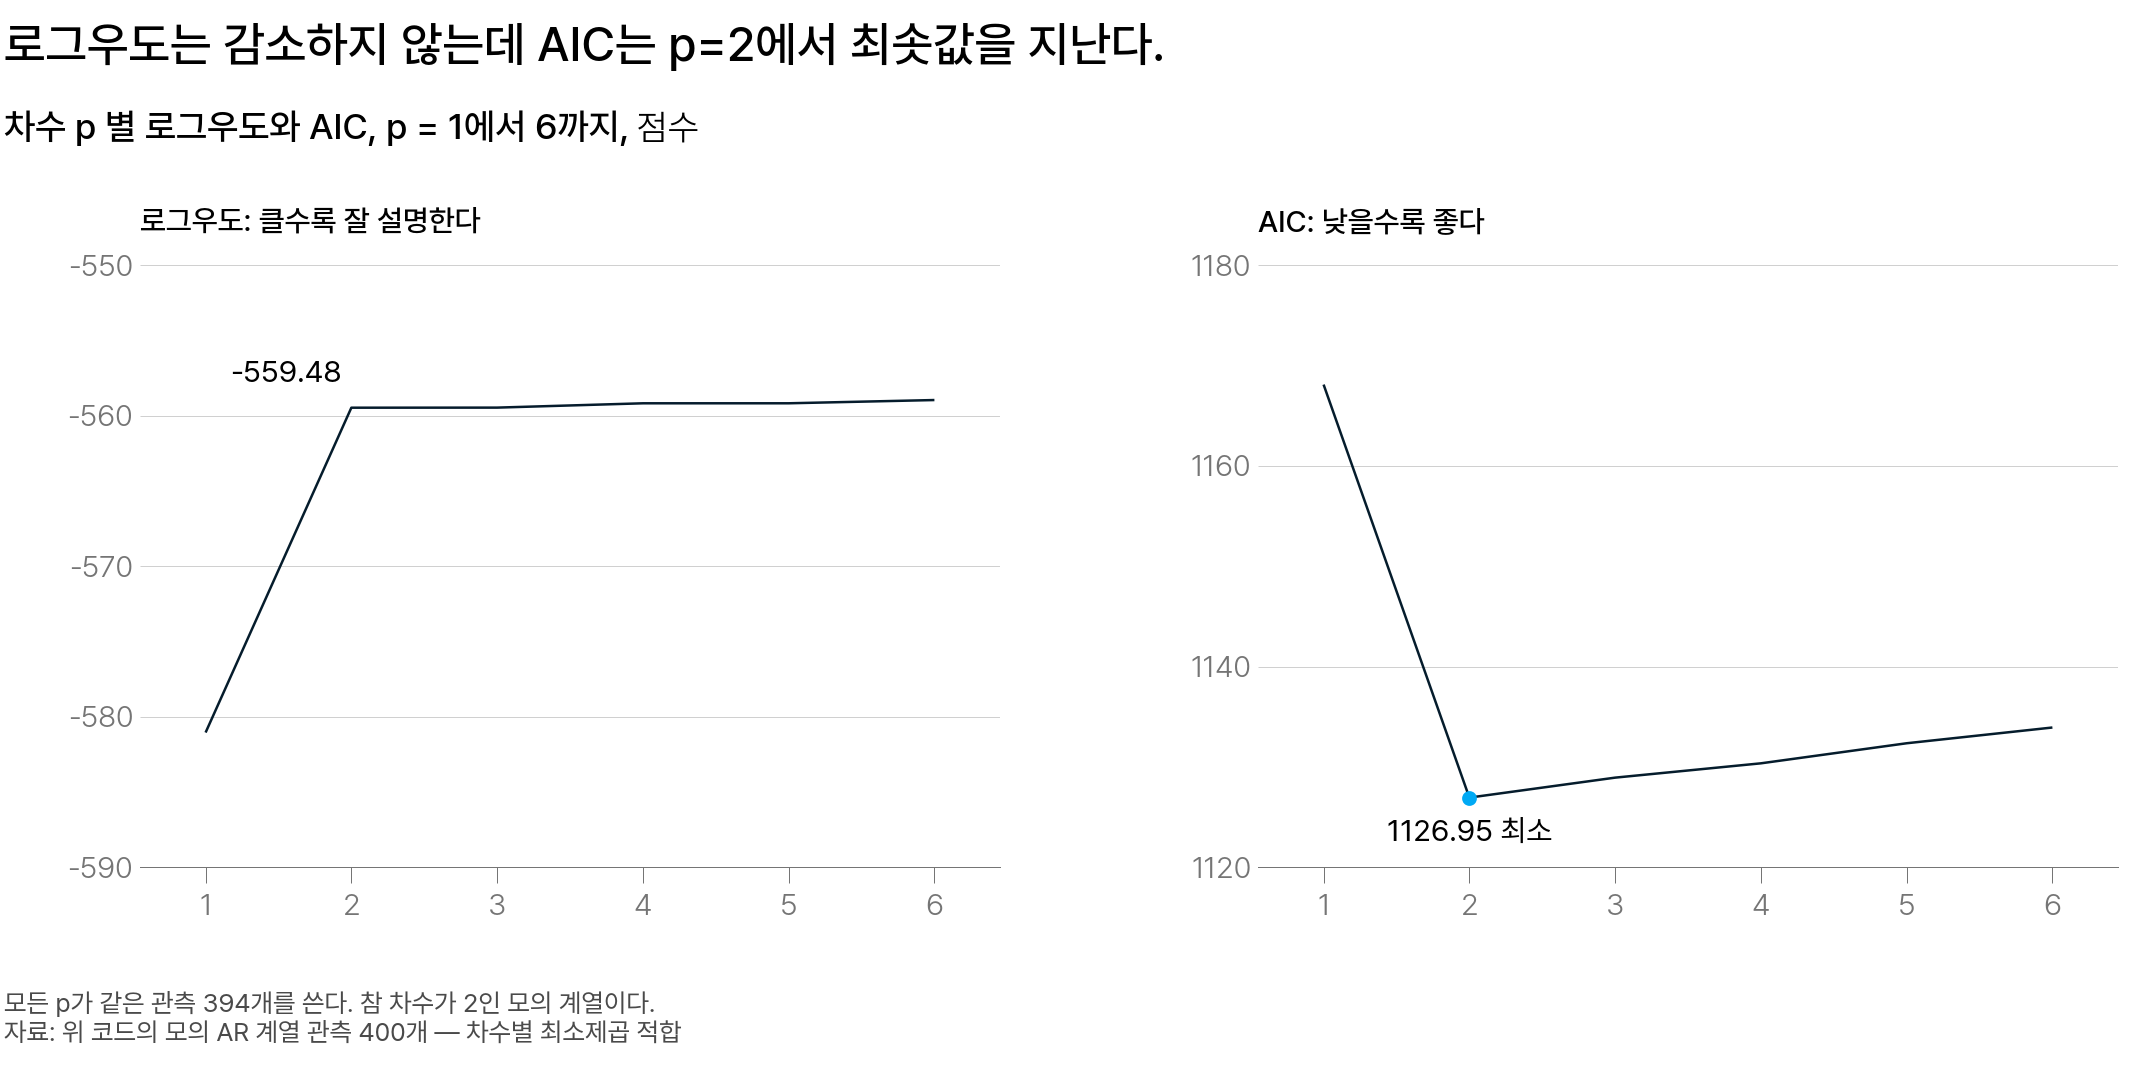

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 차수 p 를 1에서 6까지 바꿨을 때의 로그우도(왼쪽)와 AIC(오른쪽) — 오른쪽 선은 p = 2 에서 최솟값 1126.95 를 지난 뒤 다시 올라간다</em></p>

두 패널 모두 가로축은 차수 $p$, 세로축은 왼쪽이 로그우도이고 오른쪽이 AIC 입니다.

왼쪽 로그우도는 $p$ 가 커질수록 커지기만 해서 $p = 1$ 이 −581.04, $p = 6$ 이 −558.97 입니다. 이 패널만 보면 언제나 $p = 6$ 을 고르게 됩니다. 오른쪽 AIC 는 $p = 2$ 까지 내려가다가 다시 오르니, 가장 낮은 $p = 2$ 를 고릅니다.

최솟값 1126.95 를 식에 대입해 확인해 봅니다. $p = 2$ 는 계수 2개에 상수항과 오차항의 분산을 더해 $k = 4$ 이고, 로그우도가 −559.475 입니다. 대입하면 $2 \times 4 - 2 \times (-559.475) = 1126.95$ 입니다.

예측 질문의 답은 둘째 보기입니다. 로그우도는 계속 증가하지만 AIC 는 최솟값을 지난 뒤 다시 증가합니다. 이 계열을 만들 때 쓴 차수가 2 였으니, AIC 가 참 차수를 그대로 골랐습니다.

### AIC 를 언제 비교할 수 있나

다만 AIC 에는 지킬 것이 둘 있습니다.

**차분 횟수 $d$ 가 다른 모형 2개의 AIC 는 비교하지 않습니다.** 차분을 하면 계열 자체가 달라져서, 로그우도를 서로 다른 자료에서 계산한 셈이 되기 때문입니다. 그래서 $d$ 는 검정으로 먼저 정해 두고, 같은 $d$ 안에서만 AIC 를 비교합니다.

**후보 사이의 AIC 차이가 2 이하이면 둘을 가르지 않고 항이 적은 쪽을 고릅니다.** 모수를 하나 더 쓸 때 AIC 에 더해지는 값이 2 이기 때문입니다. 차이가 2 안쪽이면, 설명이 나아져 생긴 차이인지 모수를 하나 더 써서 생긴 차이인지 갈라낼 수 없습니다.

그래서 $p = 2$ 와 $p = 3$ 은 AIC 차이가 1.99 라 우열을 가리지 않고, 항이 적은 $p = 2$ 를 고릅니다. $p = 1$ 과 $p = 2$ 는 차이가 41.14 라 $p = 2$ 가 낫다고 말할 수 있습니다. 이 2 는 자연법칙이 아니라 관행입니다.

<details class="lms-extra"><summary>자세히 — AIC 차이 1.99 는 어디서 나오는가</summary>

$p$ 를 2 에서 3 으로 키우면 AIC 가 1.99 늘어납니다. 이 1.99 가 어떻게 만들어지는지 손으로 따라갑니다.

위 코드가 적합한 AR($p$) 는 계수가 $p$ 개이고, 여기에 상수항과 오차항의 분산이 더해집니다. 그래서 모수 개수는 $k = p + 2$ 입니다.

- 모수를 세면 $p = 2$ 는 $k = 4$ 이고 $p = 3$ 은 $k = 5$ 입니다.
- 패널티 항 $2k$ 를 구하면 8 과 10 이라 2 만큼 늘어납니다.
- 로그우도는 −559.4755 에서 −559.4700 으로 0.0055 늘어납니다.
- 늘어난 로그우도에 −2 를 곱하면 −0.0110 입니다.
- 둘을 더하면 $2 - 0.0110 = 1.989$ 이고, 앞에서 뺀 1.99 와 같습니다.

그래서 모수를 하나 더 써도 로그우도가 그만큼 늘지 않으면 AIC 는 올라갑니다. ARIMA($p$, $d$, $q$) 로 넓히면 계수가 $p + q$ 개라 $k = p + q + 2$ 가 됩니다.

</details>

### 자동 차수 탐색: 이웃 차수로 옮겨 가며 AIC 를 비교하는 함수

$p$ 와 $q$ 를 0 에서 5 까지만 두어도 조합이 $6 \times 6 = 36$ 개입니다. 하루 주기를 담는 계절 차수(내일 다룹니다)까지 더하면 수백 개가 됩니다.

**자동 차수 탐색(auto_arima)** 은 `pmdarima` 패키지의 함수입니다. 지금 차수의 이웃으로 옮겨 가며 AIC 를 비교하다가 더 낮은 이웃이 없으면 거기서 멈추고 그 차수를 돌려줍니다. 이웃은 지금 차수에서 $p$ 나 $q$ 를 1 만큼 늘리거나 줄인 조합이고, 둘을 함께 옮긴 것까지 세면 한 번에 8개를 적합합니다. 이렇게 이웃만 비교하는 방식이 **단계별 탐색(stepwise)** 이고, 빠짐없이 적합하는 쪽이 전수 탐색입니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/ARMAgridsearch-1.png" width="440" height="440"/>
<p align="center"><em>▲ 단계별 탐색이 (p, q) 격자를 건너간 예 — 주황 4개에서 시작해 동그라미 친 현재 차수의 이웃만 적합하며 네 단계로 옮겨 간다 (출처: fpp3 9.7)</em></p>

가로 눈금은 $q$ 이고 세로 눈금은 $p$ 입니다. 회색 점은 한 번도 적합하지 않은 조합입니다.

이제 서울 공유자전거 수요로 돌아가, 학습 336시간에서 차수를 찾아 달라고 해 봅니다.

In [ ]:
# demand — 서울 공유자전거 시간당 대여 수요, 2018년 11월 3일부터 16일까지 336시간
import pandas as pd
import pmdarima as pm

try:                                                 # LMS 실행 카드 전용 헬퍼
    raw = load_csv("datasets/SeoulBikeData.csv")
except NameError:                                    # Colab 등 헬퍼가 없는 곳
    raw = pd.read_csv("https://archive.ics.uci.edu/static/public/560/"
                      "seoul+bike+sharing+demand.zip",
                      encoding="cp1252", compression="zip")      # 8,760행 x 14열
raw.index = (pd.to_datetime(raw["Date"], format="%d/%m/%Y")      # 01/12/2017 = 2017년 12월 1일
             + pd.to_timedelta(raw["Hour"], unit="h"))           # 그 행의 시각을 더한다
raw = raw.sort_index()
hourly = raw["Rented Bike Count"].astype(float).mask(raw["Functioning Day"].eq("No"))
hourly = hourly.fillna(hourly.shift(24 * 7))     # 운영을 멈춘 시각은 1주일 전 같은 시각으로 채운다
demand = hourly.loc["2018-11-03":"2018-11-16"]   # 학습 구간 336시간
demand.index.freq = "h"

model = pm.auto_arima(demand, seasonal=True, m=24,        # 차수 조합 탐색에 1분 남짓 걸린다
                      information_criterion="aic", stepwise=True)
print(model.order, model.seasonal_order)

탐색이 고른 차수는 이렇습니다.

```
(1, 0, 1) (1, 0, 1, 24)
```

앞 괄호가 오늘 정하는 $\text{ARIMA}(p, d, q)$ 이고, $p = 1$·$d = 0$·$q = 1$ 입니다. 지난 값을 쓰는 항 하나와 지난 오차항을 쓰는 항 하나를 두고 차분은 하지 않는다는 뜻입니다.

뒤 괄호는 하루 주기를 담는 계절 항의 차수 $\text{ARIMA}(P, D, Q)_{24}$ 이고 내일 다루지만, 24시간 전 값을 몇 번 빼는지를 말하는 계절차분 횟수 $D$ 하나는 지금 봅니다.

첫날 1년 8,760시간 계열에서는 계절차분이 한 번 필요하다고 보았습니다. 그런데 탐색은 $D$ 를 0 으로 정했으니 두 결론이 어긋납니다.

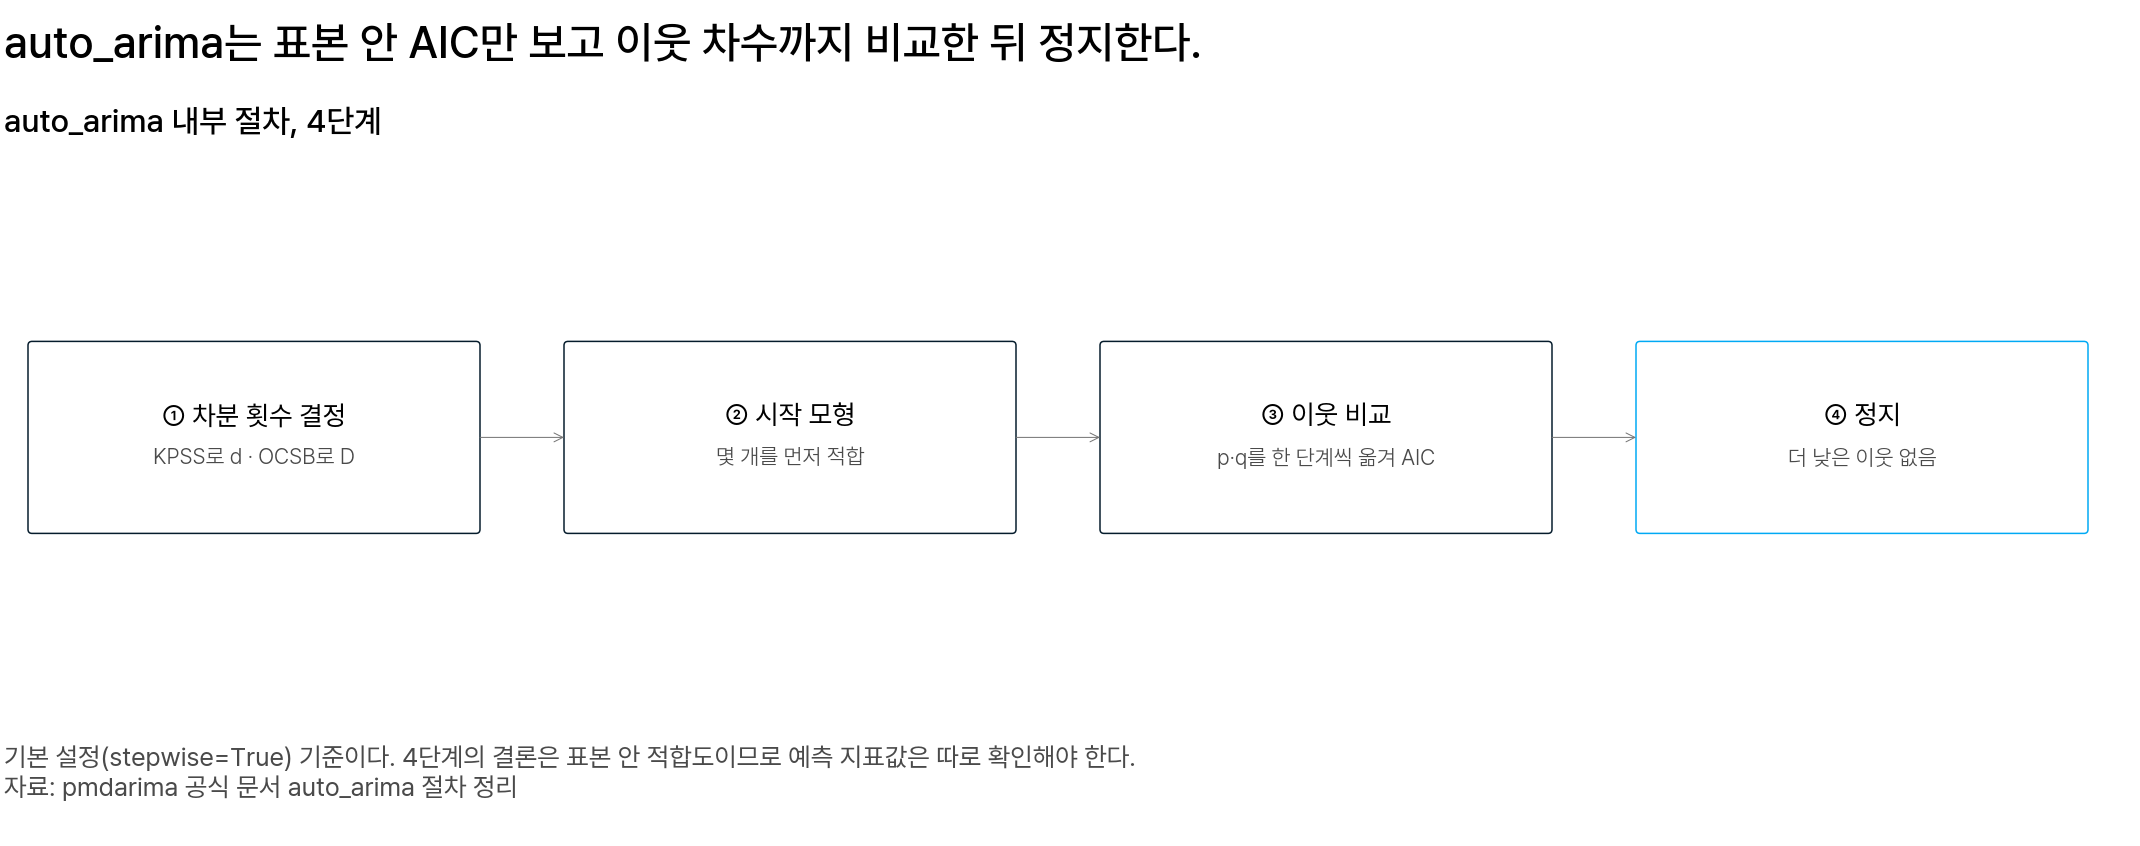

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ auto_arima 내부 절차 4단계</em></p>

①번 상자는 $d$ 와 $D$ 를 검정으로 정합니다. 직전 값을 빼는 보통 차분을 계절차분과 갈라 부를 때 **레벨 차분(level differencing)** 이라 합니다. 레벨 차분 횟수 $d$ 는 KPSS 검정이 정하고, 계절차분 횟수 $D$ 는 **OCSB 검정(OCSB test)** 이 정합니다. OCSB 는 24시간처럼 계절 주기만큼 떨어진 값들 사이에 단위근이 있는지 봅니다.

④번 상자가 멈출 때 쓰는 근거는 이미 본 336시간의 AIC 뿐입니다. 아직 보지 않은 11월 17일 24시간을 얼마나 맞히는지는 여기서 보지 않습니다. **자동 차수 탐색의 결과는 검토의 시작이지 결론이 아닙니다.**

### 탐색이 정한 D 를 받아들이지 않는 까닭

$d$ 와 $D$ 를 정한 검정 결과를 나란히 봅니다. 앞의 두 행은 탐색이 정한 것이고, 셋째 행은 첫날 우리가 정한 것입니다.

| 정할 값 | 판단 근거 | 결론 |
|---|---|---|
| 레벨 차분 $d$ | 학습 336시간의 KPSS 통계량 0.169 가 5% 임계값 0.463 보다 작아 정상성이 기각되지 않음 | 0 |
| 계절차분 $D$ | 학습 336시간의 OCSB 통계량 −6.37 이 임계값 −1.76 보다 작아 계절 단위근이 기각됨 | 0 |
| 계절차분 $D$ | 1년 8,760시간에서 계절차분한 계열의 ADF −17.0 이 임계값 −2.86 보다, KPSS 0.008 이 0.463 보다 작아 함께 정상이라는 결론 | 1 |

KPSS 는 「정상이다」가, ADF 와 OCSB 는 「단위근이 있다」가 귀무가설입니다. 레벨 차분 $d$ 는 탐색도 우리도 0 이라, 갈린 것은 계절차분 $D$ 뿐입니다.

둘째 행의 OCSB 는 계절 단위근이 있는지만 보고 주기 24 가 얼마나 남았는지는 보지 않습니다. 그래서 OCSB 가 기각해도 하루 주기가 크게 남아 있을 수 있습니다. **결론이 갈릴 때는 계절차분한 계열을 직접 검정한 셋째 행을 씁니다.** 그래서 $D = 1$ 로 둡니다.

<details class="lms-extra"><summary>더 깊이 — 단계별 탐색이 지나치는 차수 조합</summary>

①번 상자가 정한 $d$ 와 $D$ 는 뒤이은 탐색에서 다시 계산하지 않습니다. 탐색이 정한 $D = 0$ 도 그렇게 고정된 값입니다.

③번 상자는 본문에서 센 이웃 8개만 적합합니다. 2단계 떨어진 곳에 더 낮은 AIC 가 있어도, 중간 차수의 AIC 가 더 높으면 그 앞에서 멈춥니다. `stepwise=False` 로 두면 모든 조합을 적합하지만, 계절 차수까지 후보로 삼으면 수백 번 적합해야 해서 시간이 그만큼 듭니다.

$D$ 가 갈린 것은 자료가 길고 짧아서가 아닙니다. 둘째 행의 OCSB 는 계열을 그대로 두고 24시간 간격으로 떨어진 값들만 비교하고, 셋째 행은 24시간 전 값을 실제로 뺀 계열을 검정합니다. 1년 8,760시간에서 학습 구간 336시간을 뺀 나머지를 같은 방법으로 검정해도 결론은 셋째 행과 같습니다.

</details>

그래서 자동 탐색이 고른 차수는 검정 결과와 맞춰 본 뒤에 씁니다.

앞에서 자기상관함수로 좁힌 후보 넷을 모두 적합해 보니, AIC 가 가장 낮은 것이 (1, 0, 1) 입니다.

고른 뒤에는 차수를 아예 고르지 않은 모형과도 견줍니다. 자동 탐색도 사람이 고를 때와 같은 AIC 를 쓰고, 랜덤워크는 계수가 하나도 없는 비교 상대입니다.

| 방법 | 무엇을 정하나 | 사람이 하는 일 | 이 데이터에서 나온 차수와 점수 | 언제 쓰나 |
|---|---|---|---|---|
| 랜덤워크 ARIMA(0, 1, 0) | 정할 것이 없다 — 다음 값은 직전 값에 오차항만 더한 값 | 없음 | (0, 1, 0) · 11월 17일 24시간 예측이 평균 247대/시간 빗나감¹ | 다른 후보가 예측에서 이겨야 할 상대 |
| 사람이 차수를 고른 ARIMA | $p$ 와 $q$ | 그림으로 후보를 좁히고 그 가운데 AIC 최소를 고른다 | (1, 0, 1) · AIC 4,269.29 · 같은 하루에서 평균 253대/시간 빗나감 | 계열이 하나이고 형태를 눈으로 볼 때 |
| 자동 차수 탐색(auto_arima) | $p$·$d$·$q$ 와 계절 차수까지 | 탐색 범위와 점수 기준만 정해 준다 | (1, 0, 1) · AIC 4,269.29 · 같은 하루에서 평균 253대/시간 빗나감 | 계열이 많거나 후보가 수백 개일 때 |

¹ 세 행 모두 학습 336시간에 24시간 계절차분을 한 번 두고 앞 괄호만 바꿔 적합했습니다. 랜덤워크는 레벨 차분이 하나 더 들어가 계열 자체가 달라집니다. 그래서 AIC 대신, 아직 보지 않은 11월 17일 24시간을 세 모형으로 예측했습니다. 표의 수는 그 예측이 실제 값과 얼마나 어긋났는지를 평균 낸 값이고, 예측하는 방법은 내일 다룹니다.

사람이 그림으로 좁혀 고른 차수와 탐색이 고른 차수가 (1, 0, 1) 로 같습니다. 그런데 하루를 내다본 오차는 계수가 하나도 없는 랜덤워크 쪽이 247대/시간으로 더 작습니다. AIC 가 낮다고 예측까지 나은 것은 아닙니다. 실습에서는 사람이 먼저 고르고 자동 탐색으로 맞는지 확인한 다음, 예측 오차로 한 번 더 봅니다.

다만 $p$·$d$·$q$ 3개만으로는 주기 24 를 설명할 항이 없어, 그 항은 내일 더합니다.

> **[문제] 위 코드가 출력한 표에서 로그우도가 가장 큰 차수와 AIC 가 가장 낮은 차수는 같다.**
>
> O 를 고르고 싶어지는 이유는 두 열이 같은 적합 결과에서 나왔기 때문입니다. 나온 곳은 같지만 계산하는 것이 다릅니다. 로그우도는 설명한 정도만 반영하고, AIC 는 거기에 패널티 항 2k 를 더해 모수를 몇 개 썼는지까지 반영합니다. p 를 2 에서 3 으로 키우면 로그우도는 0.0055 늘지만 패널티 항은 2 늘어서 AIC 가 1.99 나빠집니다.
> 스스로 확인하려면 출력 표에서 p = 5 와 p = 6 을 비교해 보세요. 로그우도는 −559.18 에서 −558.97 로 늘었는데 AIC 는 1132.36 에서 1133.93 으로 1.57 늘었습니다. 로그우도가 늘어도 AIC 가 나빠지는 경우를 찾으면 맞게 읽은 것입니다.
> 실무에서는 후보 여럿의 로그우도가 거의 같게 나오는 일이 흔합니다. 그럴 때 로그우도가 가장 큰 후보를 고르면 항이 가장 많은 모형이 늘 뽑히므로, 고르는 기준은 AIC 로 두고 차이가 2 이하이면 항이 적은 쪽을 고릅니다.
>
> 1. O (맞다)
> 2. X (틀리다)

## 6. 오늘의 정리와 팀 토론 질문

오늘 답한 질문은 「내일 9시 수요를 맞히려면 지난 값과 지난 오차항을 각각 몇 개씩 식에 써야 하는가」였습니다.

| 주제 | 오늘 정한 것 |
|---|---|
| 1. AR | 이번 시각의 값을 직전 값에 계수를 곱해 적는다. 그 계수의 절댓값이 1 보다 작아야 돌아갈 장기 평균이 생긴다 |
| 2. MA | 지난 오차항을 설명 변수로 쓰면 자기상관이 시차 $q$ 뒤에서 절단된다 |
| 3. ARIMA | 숫자 3개는 지난 값의 개수, 차분 횟수, 오차항의 개수다 |
| 4. 차수 후보 | 막대가 어느 시차에서 경계선 안에 들어가면 절단, 천천히 줄어들면 감쇠다. 그 모양으로 후보를 좁힌다. 확정은 못 한다 |
| 5. AIC | 같은 $d$ 안에서 AIC 가 가장 낮은 후보를 고른다. 차이가 2 이하면 항이 적은 쪽이다 |

학습 336시간에 자동 차수 탐색이 고른 차수는 (1, 0, 1) 입니다. 이 차수를 336시간의 원본 수요에 차분 없이 그대로 맞추면 $\phi_1 = 0.73$, $\theta_1 = 0.32$ 가 나오고 상수항은 214대/시간입니다.

직전 시각에 1,000대가 나갔는데 예측은 900대였다고 해 봅시다. 그 시각 오차항 $\varepsilon_{t-1}$ 은 100대이고, 이번 시각 예측은 $214 + 0.73 \times 1{,}000 + 0.32 \times 100 = 976$대가 됩니다. 원본 수요에 그대로 맞춘 계수라 이 976대도 원본 수요의 예측입니다.

이 (1, 0, 1) 은 아직 잠정 차수입니다. 예측이 빗나간 크기에 규칙이 남아 있으면 후보를 다시 고릅니다.

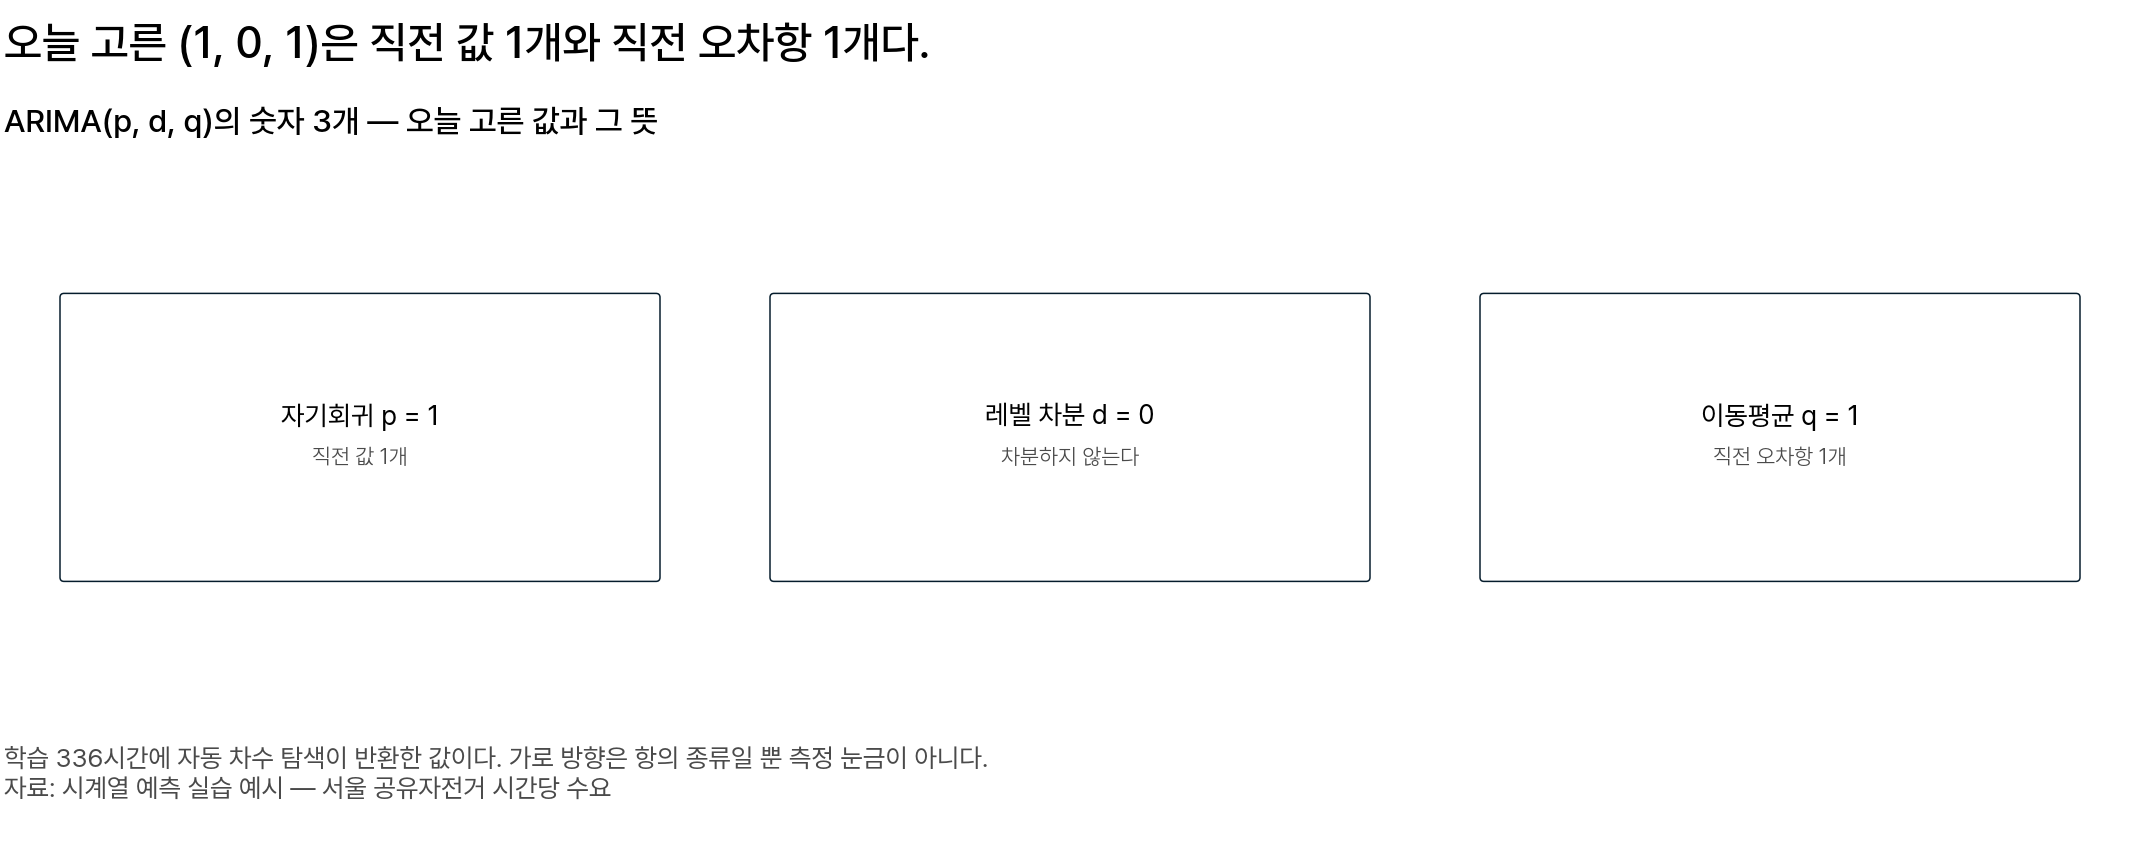

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 오늘 고른 차수 ARIMA(1, 0, 1) — 지난 값 1개와 지난 오차항 1개를 쓰고 차분은 하지 않는다</em></p>

오늘 고른 (1, 0, 1) 에 어제 정한 24시간 계절차분과 주기 24 의 계절 항을 더합니다. 그 식으로 11월 17일 토요일 하루를 예측하는 일은 내일 다룹니다.

<div style="background:#F2F2F2;color:#000000;padding:28px;border-radius:12px;border:1px solid #E6E6E6;margin-top:18px;border-left:4px solid #051C2C">
<h2 style="color:#000000;margin:0 0 10px 0">오늘의 한 문장</h2>
<div style="font-size:1.05em">"AR 은 지난 값을, MA 는 지난 오차항을 설명 변수로 쓰고, 항을 몇 개 둘지는 AIC 가 가장 낮은 후보로 좁힌 뒤 아직 보지 않은 하루에서 견줘 정합니다."</div>
</div>

## 수업에서 다룰 질문

마지막으로 답이 갈리는 문제를 하나 봅니다. 자동 탐색이 돌려준 차수 (1, 0, 1) 을 그대로 써도 되는가입니다.

각자 답을 하나 적습니다. 그 답에 얼마나 자신 있는지도 1 부터 5 까지 가운데 하나로 함께 적습니다. 1 은 거의 자신 없다는 뜻이고 5 는 매우 자신 있다는 뜻입니다. 모아서 팀의 답 분포를 본 다음, **왜 그 입장을 골랐는지**를 근거 3문장으로 주고받아 토론하고 팀의 답 하나를 제출합니다.

> **[문제] 팀 라운드 — 자동 탐색이 돌려준 차수를 그대로 쓸 것인가**
>
> 학습 구간 336시간에 자동 차수 탐색을 실행해 비계절 차수 (1, 0, 1) 을 얻었습니다. 탐색이 「더 낮은 이웃이 없다」고 판단한 근거는 그 336시간에서 계산한 AIC 뿐입니다. 아직 보지 않은 11월 17일 24시간을 얼마나 맞히는지는 재지 않았습니다. 견준 이웃도 8개뿐입니다. p 만 한 단계 옮긴 조합 2개, q 만 한 단계 옮긴 조합 2개, 둘을 함께 옮긴 조합 4개입니다. 운영팀은 내일 회의에 쓸 차수 하나를 정해 달라고 합니다. 팀 안에서 의견이 3가지로 나뉘었습니다.
> 
> - **관점 A — 돌려준 차수를 그대로 쓴다.** 고르는 기준을 AIC 로 미리 정했고 탐색은 그대로 골랐다. 사람이 손으로 고치기 시작하면 고르는 사람에 따라 답이 달라진다. 차수는 (1, 0, 1) 로 확정하고 다음 단계로 넘어간다.
> - **관점 B — 보지 않은 구간에서 다시 재고 정한다.** AIC 는 이미 본 336시간만 본다. 후보 몇 개를 남겨 두고 11월 17일 24시간을 얼마나 맞히는지 재 본 뒤에 고른다.
> - **관점 C — 탐색 범위부터 넓힌다.** 이웃 8개만 본 결과라 p 나 q 를 두 단계 옮긴 조합은 적합조차 해 보지 않았다. 모든 조합을 적합해 후보를 다시 만든 다음에 고른다.
> 
> 자기 입장 하나와 근거 3문장, 그리고 확신도를 정해 오세요.